# MIT91207 Machine Learning: Assignment 1

**Name:** Mugisha Jean Claude
**Registration number:** 26016815
**Programme:** MSc Information Technology, Level 9, Trimester 4
**Module:** MIT91207 Machine Learning
**Lecturer:** Dr Gustave Udahemuka
**Submission date:** 17 September 2026

## Note on reproducibility

Every number, table and figure in this report was produced by the scripts in `code/`
and can be regenerated in full. Nothing is quoted from memory or from a textbook.

| Item | Detail |
|---|---|
| Python | 3.9.6, virtual environment `mluok` |
| Libraries | pandas 2.3.3, scikit-learn 1.6.1, statsmodels, scipy, matplotlib |
| Random seed | 42 throughout, so all results are reproducible |
| Q6 data | `data/uscrime.txt`, 47 states, 16 variables, no missing values |
| Q7 data | `data/synthetic_ETA.csv`, 1,500 journeys, 15 variables, no missing values |
| Other questions | Data generated under a stated process, since no dataset was supplied |

To reproduce: `pip install -r requirements.txt` then `bash run_all.sh`. Console
output for each question is preserved in `output/*_console.txt`.

Where a question supplies no dataset (Questions 2, 3, 4, 5 and 8), a sample frame is
constructed that carries exactly the faults the question describes. The generating
process is written out in the script, so the conclusions can be checked against a
known ground truth. This is deliberate: it is the only way to show that a proposed
treatment recovers the right answer, because with real data the right answer is unknown.

In [1]:
# Environment check. Every result below is produced by this notebook.
%matplotlib inline
import sys, pandas, numpy, sklearn, statsmodels, scipy, matplotlib
print('python      ', sys.version.split()[0])
for m in (pandas, numpy, sklearn, statsmodels, scipy, matplotlib):
    print(f'{m.__name__:12s}', m.__version__)
import os; print('\nproject folder:', os.path.basename(os.getcwd()))
print('datasets present:', sorted(os.listdir('data')))

# Expected, benign warnings, silenced so the output stays readable:
#   ConvergenceWarning - raised by the deliberately unscaled model in Q4(a), where
#     failure to converge within 2000 iterations is itself the reported finding.
#   UserWarning from the encoder - raised in Q7 when a resampled subset contains no
#     'highway' journeys, the reference-level collision examined in Q4(d).
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

python       3.9.6
pandas       2.3.3
numpy        2.0.2
sklearn      1.6.1
statsmodels  0.14.6
scipy        1.13.1
matplotlib   3.9.4

project folder: MIT91207-Assignment1
datasets present: ['synthetic_ETA.csv', 'uscrime.txt']


# Question 1: Student early-warning system (12 marks)

## 1(a) Formulating the problem (5 marks)

The university has not asked for a prediction. It has asked for a way to decide which
students an advisory team should contact next week. That distinction governs everything
that follows, because the quantity being optimised is the quality of a ranking under a
fixed capacity constraint, not the accuracy of a label.

The target variable. "Poor academic outcome" is not yet a variable. It has to be
made one, and the choice is a policy decision and not a technical one. Three
defensible definitions are available, and they are not equivalent:

| Definition | Type | What it supports |
|---|---|---|
| Final module mark | Continuous, 0 to 100 | How far below the line a student is likely to fall |
| Pass or fail at the 50% threshold | Binary | Whether to intervene at all |
| Progression outcome at end of year | Binary, longer horizon | Retention planning |

The prediction horizon is part of the problem definition. A model that predicts the
final mark using the final coursework score is useless, because by the time that score
exists the outcome is already settled. The system must be specified as: given only the
information observable at week *t*, predict the outcome at end of module. This makes the
feature set a function of *t* and forces attendance, learning-management-system
engagement and early assessment marks to be truncated at the prediction date. Section
2(d) of this report treats the same problem in a recommendation setting.

My recommendation is to treat it as both, with the regression as the primary model.
The underlying quantity, the final mark, is continuous and the dichotomy at 50% is an
administrative convention applied to it. Fitting the continuous outcome and then
thresholding preserves information that a direct classifier discards. A student
predicted at 49% and a student predicted at 18% are both classified "at risk", but they
require entirely different interventions, and the classifier cannot tell them apart. The
regression output also supports a conversation the classifier cannot support, namely what
mark the student needs on the remaining assessment to recover.

The classification framing is still required, for two reasons. The decision itself is
binary, so a threshold has to exist somewhere. And a calibrated probability of failure is
the correct input to a capacity-constrained triage rule, because it can be combined with
the cost of a missed intervention to produce a defensible cut-off. The practical design
is therefore a regression model on the mark, plus a calibrated classifier used for
ranking, with the two reconciled at the point of decision.

What the university is really buying is a ranking. With, say, four advisors and 900
students, only the top forty or so cases will ever be contacted. A model with modest
overall accuracy but a well-ordered top decile is more useful than an accurate model that
mixes the top decile, and this is why the evaluation in 1(c) and in Question 5 is framed
around ranking quality and subgroup behaviour, not raw accuracy.

## 1(b) Two modelling approaches (5 marks)

Classification approach: penalised logistic regression, moving to gradient boosting if
the data justifies it.

Logistic regression is the right starting point here, not a fallback. It produces a
probability that is directly interpretable as a risk score, the coefficients can be shown
to an academic board that will reasonably ask why a particular student was flagged, and
with L2 penalisation it behaves stably when attendance and engagement measures are
correlated, which they invariably are. Question 7 of this report demonstrates that
penalisation mainly buys coefficient stability more than accuracy, and that is what is wanted when the output has to be defended.

How the prediction supports the decision: the model returns P(fail) for every enrolled
student each week. Advisors receive a ranked list with the probability attached, banded
into three tiers. Above 0.70, contact this week. Between 0.40 and 0.70, monitor and
contact if the trend worsens. Below 0.40, no action. The bands are set from the advisory
capacity and the relative cost of the two errors, not from the default 0.50 cut-off,
which corresponds to no particular institutional preference. Because the probability is
calibrated, "seventy per cent" can be checked against the observed failure rate of
students given that score, and the board can audit that claim.

Regression approach: gradient-boosted regression trees on the final mark.

The relationship between engagement and attainment is not linear. Attendance rising from
30% to 50% matters a great deal, and from 80% to 95% matters very little. A boosted tree
model captures that saturation without anyone having to specify it, and it handles the
interaction between prior grades and current engagement that a linear model would need to
be told about explicitly. Ridge regression is the appropriate comparator, and on a
first-year cohort with few features it will often match the boosted model, a result worth knowing before committing to the more complex option.

How the prediction supports the decision: the model returns a predicted mark with an
interval. The actionable quantity is the predicted distance from the pass mark. A student
predicted at 47 plus or minus 6 is a different case from one predicted at 25 plus or minus
6, even though both are below the line, and the intervals let an advisor distinguish a
confident prediction from an uncertain one. The intervals matter more than the point
estimate for a borderline student, because that is where the intervention decision is
genuinely difficult.

Why run both. They fail differently. If the classifier flags a student the regression
places at 62, that disagreement is itself a signal, usually that the student's pattern is
unusual relative to the training cohort. Routing disagreements to human review is a
cheap and effective safeguard.

## 1(c) Two factors beyond predictive accuracy (2 marks)

Subgroup performance, and the asymmetry of the two errors. Aggregate accuracy is an
average, and averages conceal exactly the failures that matter here. Question 5 of this
report measures this directly on a comparable problem: an overall AUC of 0.731 was
composed of subgroup AUCs ranging from 0.695 to 0.763, and subgroup recall ranged from
0.275 to 0.529. A 25 percentage point spread in recall means the system finds half the
at-risk students in one group and a quarter in another, while reporting a single
respectable headline number. In this university setting the groups that matter are likely
to be part-time students, students entering through non-standard qualifications, and
students whose engagement is off-campus and therefore under-recorded by the
learning-management system. The two errors are also not symmetric. A false negative is a
student who fails without ever being contacted. A false positive costs an advisor twenty
minutes. Accuracy weights these equally, an indefensible weighting, so the model must be
evaluated on recall within each subgroup at the operating threshold, and the threshold
itself must be justified against that asymmetry.

The gap between prediction and action, and the feedback loop the system creates. The
model finds association, not cause. Low learning-management-system engagement predicts
failure, but it is largely a symptom. A student in financial difficulty, working night
shifts, will show low engagement, and an intervention aimed at raising their click rate
addresses the indicator and not the cause. The features must therefore be
interrogated for whether they are actionable at all before the system is allowed to drive
interventions, a point developed at length in Question 6(d). There is also a loop that
most deployments overlook: once interventions begin, a successful intervention makes the
prediction wrong, so the model's apparent accuracy degrades precisely when it is working.
Without recording which students were contacted and treating that as a variable, the
retraining cycle will progressively unlearn the signal that made the system useful. In
addition, a student labelled "at risk" may be treated differently by staff and may
internalise the label, so the prediction can contribute to the outcome it forecasts.
Under Rwanda's Law No. 058/2021 relating to the protection of personal data and privacy,
profiling students in this way also carries transparency and lawful-basis obligations
that need to be settled before deployment, not after.

# Question 2: Course-recommendation preprocessing (13 marks)

## 2(a) Preprocessing pipeline design (5 marks)

The four faults the question lists are not equally serious, and treating them as a
uniform cleaning checklist is the main risk. Ordering matters, because several of the
operations interact.

Order of operations, and why.

1. **Duplicates first.** Deduplicating after computing statistics would mean the
   statistics were computed on inflated counts. Two kinds exist here and they need
   different treatment. Exact repeated rows are ingestion artefacts and can be dropped
   outright. Repeated learner-course pairs with different timestamps are not errors at
   all, they are re-enrolments, and dropping them blindly destroys real behaviour. In the
   sample frame this distinction removed 2 rows as re-enrolments while retaining the most
   recent record for each pair.
2. **Category harmonisation second,** because grouped statistics computed later depend on
   the grouping key being correct. `"Data Science"`, `" data science"`, `"DATA SCIENCE"`
   and `"Data  Science"` are one category recorded four ways. Left alone they become four
   one-hot columns, each with a quarter of the support, and the model sees four rare
   categories instead of one common one. In the sample frame, 9 distinct raw strings
   collapse to 3 genuine categories.
3. **Missing ratings third.** The critical judgement is that a missing rating is not a
   missing number, it is an absent behaviour. Learners who abandon a course rarely rate
   it. Imputing the mean assigns an average opinion to people who were too indifferent to
   express one, which biases the recommender towards courses that are quietly disliked.
   The treatment is to impute a central value so the row remains usable, and to retain a
   binary `rating_missing` indicator so the model can learn what the absence itself
   means. Question 3 develops this argument with measured consequences.
4. **Scaling last, and fitted on training rows only.** `minutes_watched` spans 30 to
   1,450 while `rating` spans 2.5 to 5.0. Any method operating on distance, which
   includes k-nearest-neighbour recommenders, matrix factorisation with regularisation,
   and anything penalised, will be dominated by the wider variable purely because of its
   units.

Effect on the downstream model. Skipping harmonisation fragments the category signal
and weakens any content-based component. Mean-imputing ratings without an indicator
introduces a systematic bias towards recommending material that learners quietly
abandoned. Fitting the scaler on all rows leaks the test distribution into training and
produces an optimistic offline estimate that will not survive contact with live traffic.
Deduplicating carelessly removes genuine repeat engagement, one of the strongest signals a recommender has.

On what not to do. Rows with missing ratings should not be dropped. In the sample
frame that would discard 3 of 15 records, and the discarded rows are systematically the
disengaged learners, that is, the population the recommender most needs to model.

## 2(b) Implementation (5 marks)

The full script is `code/q2_recommender_prep.py`. The core operations:


Measured result:

```
rows=15  exact duplicates=0  missing ratings=3  distinct category strings=9
raw category labels: [' data science', 'AI / ML', 'AI/ML', 'DATA SCIENCE',
                      'Data  Science', 'Data Science', 'Databases', 'ai/ml', 'databases']

STEP 1  repeat learner-course rows removed (kept most recent): 2
STEP 2  9 raw strings -> 3 canonical: ['AI/ML', 'Data Science', 'Databases']
STEP 3  category medians from training rows: {'AI/ML': 4.5, 'Data Science': 4.0,
                                              'Databases': 3.0}
STEP 5  StandardScaler fitted on training rows only
            variable  train mean  train scale
       rating_filled        3.83         0.71
     minutes_watched      496.67       479.92
```

The scale disparity is worth stating numerically, since it is the reason step 5 exists:
before scaling, `minutes_watched` has a standard deviation of 536.34 against 0.77 for
`rating`, a ratio of roughly 700 to 1.

## 2(c) Two engineered features (2 marks)

`engagement_ratio` = learner's minutes on a course divided by the median minutes for
that course. Raw watch time confounds two different things, how engaged the learner is
and how long the course happens to be. A 45-minute course watched in full and a
1,400-minute course abandoned after 45 minutes produce the same raw value and mean
opposite things. Normalising by the course median separates them. For the recommendation
problem this matters because the quantity of interest is whether this learner found this
material worth their time relative to how other learners treated it, a completion signal that does not depend on a rating being given. In the sample frame the
feature ranges from 0.375 to 4.0, cleanly separating skimming from deep engagement.

`prior_completion_rate` = the proportion of the learner's *earlier* courses that they
completed. Learners differ systematically in follow-through, and that disposition is
one of the strongest available predictors of whether a recommendation will be acted on.
Recommending an advanced twelve-week course to a learner who has abandoned four of five
enrolments is a poor recommendation even if the topic matches perfectly. The
implementation detail is the entire point: it uses `shift()` before `expanding().mean()`,
so a record never contributes to its own feature value. Without the shift this is a
textbook leak, since the current course's completion status would be encoded in the
feature used to predict it.

## 2(d) Preventing information from the future (1 mark)

Split on time, not at random, and fit every statistic on the past side only.

Concretely, four things are required. Records are ordered by timestamp and cut at a date,
so training ends before validation begins. Every fitted quantity, meaning imputation
medians, scaler means and scales, and category vocabularies, is learned on the training
window and applied unchanged afterwards. Any per-learner aggregate is computed with an
expanding window over strictly earlier records, as `shift()` enforces above.
And features that could only be known after the fact, such as final course rating or
total watch time, are excluded from any model that scores a learner mid-course.

The check is mechanical and is run by the script:

```
train window 2026-01-05 .. 2026-04-15  (n=9)
test  window 2026-04-21 .. 2026-06-01  (n=4)
overlap: NONE
first-ever record for any learner carrying non-zero history: False (must be False)
```

The second assertion is the one that catches real bugs. Any learner's first record must
carry a prior-completion rate of zero, because at that moment they have no history. If it
does not, an aggregate has been computed over the full series and the future has entered
the training data.

### Question 2 code: `code/q2_recommender_prep.py`

In [2]:
"""
Q2(b)(c)(d) - preprocessing pipeline for the course-recommendation dataset.
A sample frame is constructed carrying every fault named in the question:
missing ratings, duplicate records, inconsistent category labels, and
numeric variables on very different scales.
"""
import numpy as np, pandas as pd
from sklearn.preprocessing import StandardScaler
pd.set_option("display.width", 200)
RS = 42; rng = np.random.default_rng(RS)

raw = pd.DataFrame({
 "learner_id":[101,101,102,103,104,104,105,106,107,108,109,101,110,111,112],
 "course_title":["Intro to Python","Intro to Python","Data Viz","Intro to Python","Deep Learning",
                 "Deep Learning","Data Viz","SQL Basics","Deep Learning","SQL Basics","Intro to Python",
                 "Data Viz","SQL Basics","Deep Learning","Data Viz"],
 "course_category":["Data Science"," data science","DATA SCIENCE","Data  Science","AI/ML","ai/ml",
                    "Data Science","Databases","AI / ML","databases","Data Science","DATA SCIENCE",
                    "Databases","ai/ml","Data Science"],
 "rating":[4.5,4.5,np.nan,3.0,5.0,5.0,np.nan,2.5,4.0,3.5,4.0,4.0,np.nan,4.5,3.5],
 "completion_status":["completed","completed","dropped","completed","completed","completed",
                      "in_progress","dropped","completed","completed","completed","completed",
                      "in_progress","completed","dropped"],
 "timestamp":pd.to_datetime(["2026-01-05","2026-01-05","2026-01-11","2026-02-02","2026-02-14",
                             "2026-02-14","2026-03-01","2026-03-08","2026-03-19","2026-04-02",
                             "2026-04-15","2026-04-21","2026-05-03","2026-05-17","2026-06-01"]),
 "minutes_watched":[320,320,45,610,1450,1450,90,30,1180,240,505,275,60,1320,150],
 "courses_taken_before":[0,0,3,1,7,7,2,0,5,1,4,2,1,6,3],
})

print("="*80); print("BEFORE CLEANING")
print(raw.to_string(index=False))
print(f"\nrows={len(raw)}  exact duplicates={raw.duplicated().sum()}  "
      f"missing ratings={raw.rating.isna().sum()}  "
      f"distinct category strings={raw.course_category.nunique()}")
print("raw category labels:", sorted(raw.course_category.unique()))
print("\nScale disparity (raw units):")
print(raw[["rating","minutes_watched","courses_taken_before"]].describe().T[["mean","std","min","max"]]
      .to_string(float_format=lambda v: f"{v:10.2f}"))

df = raw.copy()

# 1. duplicates: exact, then business-key duplicates
df = df.drop_duplicates()
before_key = len(df)
df = df.sort_values("timestamp").drop_duplicates(subset=["learner_id","course_title"], keep="last")
print("\n"+"="*80); print("STEP 1  de-duplication")
print(f"  exact duplicates removed : {len(raw)-before_key}")
print(f"  repeat learner-course rows removed (kept most recent): {before_key-len(df)}")

# 2. category harmonisation
def norm(s):
    s = s.strip().lower().replace("/", " ").replace("-", " ")
    s = " ".join(s.split())
    return {"data science":"Data Science","ai ml":"AI/ML","databases":"Databases"}.get(s, s.title())
df["course_category"] = df.course_category.map(norm)
print("\n"+"="*80); print("STEP 2  category harmonisation")
print(f"  {raw.course_category.nunique()} raw strings -> {df.course_category.nunique()} canonical: "
      f"{sorted(df.course_category.unique())}")

# 3. missing ratings: indicator + group median, fitted on training rows only
df = df.sort_values("timestamp").reset_index(drop=True)
cut = df.timestamp.quantile(0.7)
train_mask = df.timestamp <= cut
df["rating_missing"] = df.rating.isna().astype(int)
med_by_cat = df.loc[train_mask].groupby("course_category").rating.median()
global_med = df.loc[train_mask].rating.median()
df["rating_filled"] = df.rating.fillna(df.course_category.map(med_by_cat)).fillna(global_med)
print("\n"+"="*80); print("STEP 3  missing ratings")
print(f"  cut-off for statistics: {cut.date()}  (train rows only, no future information)")
print(f"  category medians from training rows: {med_by_cat.round(2).to_dict()}")
print(f"  imputed {df.rating_missing.sum()} ratings; 'rating_missing' retained as a signal "
      "(non-response often means disengagement, not a neutral score)")

# 4. engineered features (Q2c)
df["engagement_ratio"] = (df.minutes_watched / df.groupby("course_title")
                          .minutes_watched.transform("median")).round(3)
df["is_completed"] = (df.completion_status == "completed").astype(int)
df = df.sort_values(["learner_id","timestamp"])
df["prior_completion_rate"] = (df.groupby("learner_id").is_completed
                               .transform(lambda s: s.shift().expanding().mean())).fillna(0).round(3)
df["experience_band"] = pd.cut(df.courses_taken_before, [-1,0,2,5,np.inf],
                               labels=["new","light","regular","heavy"])
print("\n"+"="*80); print("STEP 4  engineered features")
print("  engagement_ratio      = learner minutes / median minutes for that course")
print("  prior_completion_rate = share of the learner's EARLIER courses completed (shift() before expanding())")
print("  experience_band       = banded courses_taken_before")

# 5. scaling, fitted on training rows only
num = ["rating_filled","minutes_watched","courses_taken_before","engagement_ratio"]
sc = StandardScaler().fit(df.loc[train_mask, num])
df[[c+"_z" for c in num]] = sc.transform(df[num])
print("\n"+"="*80); print("STEP 5  scaling (StandardScaler fitted on training rows only)")
print(pd.DataFrame({"variable":num,"train mean":sc.mean_.round(2),"train scale":sc.scale_.round(2)})
      .to_string(index=False))

print("\n"+"="*80); print("AFTER CLEANING")
cols = ["learner_id","course_title","course_category","rating","rating_filled","rating_missing",
        "engagement_ratio","prior_completion_rate","experience_band"]
print(df[cols].to_string(index=False))
model_cols=[c for c in cols if c!="rating"]
print(f"\nrows {len(raw)} -> {len(df)}   missing values in modelling columns: {df[model_cols].isna().sum().sum()}"
      f"   (raw rating column retained with {int(df.rating.isna().sum())} NaN for audit)")

# Q2(d) temporal integrity check
print("\n"+"="*80); print("Q2(d)  LEAKAGE CHECK")
tr, te = df[df.timestamp<=cut], df[df.timestamp>cut]
print(f"  train window {tr.timestamp.min().date()} .. {tr.timestamp.max().date()}  (n={len(tr)})")
print(f"  test  window {te.timestamp.min().date()} .. {te.timestamp.max().date()}  (n={len(te)})")
print(f"  overlap: {'NONE' if tr.timestamp.max() < te.timestamp.min() else 'PRESENT - leakage'}")
bad = df.groupby("learner_id").apply(
    lambda g: (g.prior_completion_rate.notna() &
               (g.index.to_series().rank()==1) & (g.prior_completion_rate!=0)).any(), include_groups=False)
print(f"  first-ever record for any learner carrying non-zero history: {bool(bad.any())} (must be False)")
df.to_csv("output/q2_cleaned.csv", index=False)
print("\nwritten: output/q2_cleaned.csv")

BEFORE CLEANING
 learner_id    course_title course_category  rating completion_status  timestamp  minutes_watched  courses_taken_before
        101 Intro to Python    Data Science     4.5         completed 2026-01-05              320                     0
        101 Intro to Python    data science     4.5         completed 2026-01-05              320                     0
        102        Data Viz    DATA SCIENCE     NaN           dropped 2026-01-11               45                     3
        103 Intro to Python   Data  Science     3.0         completed 2026-02-02              610                     1
        104   Deep Learning           AI/ML     5.0         completed 2026-02-14             1450                     7
        104   Deep Learning           ai/ml     5.0         completed 2026-02-14             1450                     7
        105        Data Viz    Data Science     NaN       in_progress 2026-03-01               90                     2
        106      SQL Bas

# Question 3: Missing data in loan default prediction (13 marks)

The analysis uses a 3,000-record loan book generated under a known process, so that the
true values behind the gaps are available for comparison. The missingness mechanisms are
deliberately realistic: income is under-reported by informally employed applicants, and
credit scores are absent for applicants with no borrowing history. Script:
`code/q3_missing_data.py`.

```
                 missing     %
income               506  16.9
years_employed       255   8.5
credit_score         492  16.4
employment_type      122   4.1
```

## 3(a) Critical evaluation of zero-filling (5 marks)

The proposal is wrong, and it is worth being precise about why, because "zero is a bad
imputation" is not an argument. Zero is a legitimate value for some financial variables
and a nonsensical one for others, and the distinction turns on what zero means on each
variable's own scale.

Zero is a real, meaningful value on some of these fields and not on others. A loan
balance of zero means no outstanding debt. A missed-payment count of zero means a clean
record. On those fields, zero-filling does not merely add noise, it writes a specific and
usually favourable claim into the data. Applied to `n_prev_loans`, it converts "we do not
know their borrowing history" into "they have never borrowed", a materially different statement to a credit committee.

On other fields zero is outside the admissible range entirely. A credit score is
defined on 300 to 850. Zero is not a low score, it is not a score. Placing 492 applicants
at zero creates a cluster 300 points below the legal minimum, roughly 3.5 standard
deviations outside the observed distribution, and any model will read that as
overwhelming evidence of default risk. The measured consequence appears in 3(d).

The distortion reaches the geometry the model depends on. In the generated book the applicants
with missing income truly earn between 64,895 and 1,390,624, with a median of 302,620,
slightly above the observed median of 296,520. These are not poor applicants. They are
mostly self-employed and informally employed people who did not supply a payslip.
Zero-filling moves them 1.50 standard deviations below the median of the observed
distribution, inverting their true position.

Derived variables are corrupted silently. Debt-to-income is the single most
important ratio in consumer lending, and `loan_amount / income` becomes a division by
zero for all 506 affected applicants. Depending on the implementation this yields
infinity, a NaN that propagates, or a silently clipped maximum. Any of the three makes
those applicants look like the worst credits in the portfolio.

It confounds two populations that must stay separate. After zero-filling, an
applicant with a genuinely low income and an applicant who declined to state their income
are the same record. These are different credit risks and, under most regulatory regimes,
attract different treatment. The information distinguishing them has been erased rather
than modelled.

The damage is also not spread evenly. Because the missingness is not random, it falls systematically. The script tests
this directly. Testing missingness against the outcome alone is insufficient and would
have cleared two of the three fields:

```
Default rate by whether the field is missing:
  income          missing: 0.247   present: 0.251   Welch p = 8.66e-01  -> consistent with MCAR
  years_employed  missing: 0.204   present: 0.254   Welch p = 5.94e-02  -> consistent with MCAR
  credit_score    missing: 0.183   present: 0.263   Welch p = 4.45e-05  -> NOT MCAR

Missingness tested against an OBSERVED COVARIATE (employment_type):
  income          chi2 p = 4.83e-77  -> MAR, depends on employment_type
                  missing rate: {'informal': 0.417, 'salaried': 0.068, 'self_employed': 0.177}
```

Income is missing for 41.7% of informally employed applicants against 6.8% of salaried
applicants. A target-only test returns p = 0.87 and would have declared it
missing-completely-at-random. Because the missingness concentrates in one employment
class, zero-filling imposes its damage almost entirely on informal-sector applicants, who
in the Rwandan market are the majority of the addressable population. This is the
mechanism by which a naive imputation choice becomes a systematic lending bias.

## 3(b) A defensible strategy (3 marks)

The strategy must distinguish variables by type and, more importantly, by *why* the value
is absent. The two questions are separate and both have to be answered.

First, classify the mechanism. Missing-completely-at-random means the gap is unrelated
to anything, and almost nothing in a loan book qualifies. Missing-at-random means the gap
depends on other observed variables, as the chi-square result above establishes
for income: it depends on employment type, and it is recorded. Conditional imputation is
valid here. Missing-not-at-random means the gap depends on the unobserved value itself, and
credit score is the clear case. The cross-tabulation shows all 492 absent scores belong to
applicants with no prior loans:

```
no prior loans  False  True
score missing
False            2415     93
True                0     492
```

This is not a gap to be filled. It is a structural fact about thin-file customers, and
imputing any score onto that population fabricates a credit history that does not exist.

Second, apply a treatment matched to the type and the mechanism.

| Variable class | Treatment | Reasoning |
|---|---|---|
| Skewed monetary (income, loan amount) | Median from training rows, plus missing indicator | Median resists the right skew that makes the mean misleading on income data |
| Continuous non-monetary (years employed) | Median or conditional median within employment type, plus indicator | MAR given employment type, so conditioning recovers more than a global statistic |
| Structural absence (credit score) | Explicit `no_credit_file` flag, value held separately from the score scale | The applicant has no score; a thin file is a distinct underwriting category |
| Categorical (employment type) | `not_reported` as its own level, never the mode | Non-response is itself informative; imputing the mode invents an employment status |
| Target | Never imputed | Rows without a known outcome are excluded from supervised training |

Third, retain the indicator in every case. If non-response carries no information the
model will assign the indicator a near-zero coefficient and nothing is lost. If it does
carry information, and here it plainly does, that information is preserved instead of
being averaged away. This is the cheapest insurance available in the whole pipeline.

Fourth, learn every statistic on training rows only, and persist it. A median computed
over the full dataset leaks the test distribution; a median recomputed at scoring time
makes today's decision depend on who else applied today, and that is indefensible to an applicant and to a regulator.

Listwise deletion should be rejected explicitly. The measurement in 3(d) shows it retains
only 62% of training rows and shifts the observed default rate from 0.250 to 0.276, because
the discarded records are not a random sample.

## 3(c) A pipeline-ready function (3 marks)

Implemented as a scikit-learn transformer so it composes inside a `Pipeline` and inherits
the fit/transform separation that prevents leakage by construction. Full source in
`code/q3_missing_data.py`.


Assumptions and their limits. The median is a point estimate, so single imputation of
this kind understates uncertainty: the model treats an imputed income as being known as
precisely as a reported one. Multiple imputation addresses that and should be preferred
where the downstream use requires calibrated intervals and not a ranking. The
transformer also assumes the missingness mechanism is stable between training and
production, an assumption that has to be monitored and not believed, since a
change in application-form design can alter it overnight.

## 3(d) Consequences for the model and for applicants (2 marks)

Three treatments, identical splits, identical model, so the only difference is the
handling of gaps:

| Treatment | Test AUC | Brier score | Note |
|---|---|---|---|
| Zero-fill, as proposed by management | 0.6659 | 0.1772 | |
| Type-aware median with indicators | **0.7575** | **0.1586** | |
| Complete-case deletion | 0.7524 | 0.1611 | Retains 1,397 of 2,250 rows; default rate shifts 0.250 to 0.276 |

Model performance. Zero-filling costs 9.2 points of AUC, from 0.758 to 0.666. On a
discrimination scale where 0.5 is a coin toss, that is roughly a third of all the signal
the model had. The Brier score, which measures the accuracy of the probabilities rather
than the ranking, worsens by 12%, so the predicted probabilities are not merely ordered
worse, they are numerically wrong. Complete-case deletion very nearly matches the proper
treatment on these metrics but does so having discarded 38% of the training data, and its
retained sample has a default rate 2.6 percentage points above the true one. That bias
does not appear in the AUC and would surface later as a miscalibrated portfolio.

Decisions about individual applicants. This is where the abstract metric becomes a
person. Of 750 test applicants, 228 have at least one missing field.

```
mean predicted default probability, those applicants:
    zero-fill      0.2883
    type-aware     0.2373
largest single shift: 0.3342 in predicted probability
at a 20% decline threshold, 75 applicants (32.9% of those with gaps) receive a
    different decision purely from the imputation choice
at a 30% decline threshold, 31 applicants (13.6%) receive a different decision
```

One applicant's assessed probability of default moves by 33 percentage points depending
on a preprocessing default that nobody would think to document. At a 20% decline
threshold, a third of applicants with any data gap are decided differently. None of these
people changed. Their circumstances did not change. A line of code changed.

Because the gaps concentrate in informally employed applicants, as established in 3(a),
those reversals are not spread evenly across the applicant pool. They fall on a specific
economic class, which converts a technical shortcut into a fair-lending exposure. That is
the argument to put to the management team: the proposal is not a simplification that
costs a little accuracy, it is an undocumented change in credit policy.

### Question 3 code: `code/q3_missing_data.py`

In [3]:
"""
Q3 - loan default: why zero-filling is wrong, and a defensible alternative.
"""
import numpy as np, pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, brier_score_loss
from scipy import stats
RS = 42; rng = np.random.default_rng(RS)
N = 3000

# ---- construct a loan book with a realistic, NON-random missingness mechanism ----
income = np.round(rng.lognormal(12.6, 0.55, N))                 # RWF-scale annual income
years_employed = np.clip(rng.gamma(2.2, 2.4, N), 0, 40)
loan_amount = np.round(income * rng.uniform(0.15, 1.4, N))
credit_score = np.clip(rng.normal(640, 85, N), 300, 850)
n_prev_loans = rng.poisson(1.6, N)
dti = loan_amount / income
logit = (-3.1 + 2.3*dti - 0.010*(credit_score-640) - 0.10*years_employed
         + 0.22*n_prev_loans + rng.normal(0, 0.45, N))
default = rng.binomial(1, 1/(1+np.exp(-logit)))
df = pd.DataFrame({"income":income,"years_employed":years_employed,"loan_amount":loan_amount,
                   "credit_score":credit_score,"n_prev_loans":n_prev_loans,
                   "employment_type":rng.choice(["salaried","self_employed","informal"],N,p=[.5,.3,.2]),
                   "default":default})
truth = df.copy()

# missingness mechanisms
p_inc = 0.06 + 0.34*(df.employment_type=="informal") + 0.10*(df.employment_type=="self_employed")
df.loc[rng.random(N) < p_inc, "income"] = np.nan                          # MAR/MNAR: informal earners
df.loc[rng.random(N) < np.where(df.employment_type=="informal",.30,.05), "years_employed"] = np.nan
thin = df.n_prev_loans == 0
df.loc[thin & (rng.random(N) < 0.85), "credit_score"] = np.nan            # MNAR: no file, no score
df.loc[rng.random(N) < 0.04, "employment_type"] = np.nan

print("="*80); print("1. MISSINGNESS PROFILE")
prof = pd.DataFrame({"missing":df.isna().sum(),"%":(df.isna().mean()*100).round(1)})
print(prof[prof.missing>0].to_string())
print("\nDefault rate by whether the field is missing (evidence against MCAR):")
for col in ["income","years_employed","credit_score"]:
    m = df[col].isna()
    t,p = stats.ttest_ind(df.default[m], df.default[~m], equal_var=False)
    print(f"  {col:15s} missing: {df.default[m].mean():.3f}   present: {df.default[~m].mean():.3f}"
          f"   Welch p = {p:.2e}  -> {'NOT MCAR' if p<0.05 else 'consistent with MCAR'}")
print("\nMissingness tested against an OBSERVED COVARIATE (employment_type):")
for col in ["income","years_employed"]:
    tab = pd.crosstab(df[col].isna(), df.employment_type)
    chi2, p, _, _ = stats.chi2_contingency(tab)
    rate = (tab.loc[True] / tab.sum()).round(3).to_dict()
    print(f"  {col:15s} chi2 p = {p:.2e}  -> {'MAR, depends on employment_type' if p<0.05 else 'no covariate dependence'}")
    print(f"                  missing rate by employment type: {rate}")
print("\n  Note: testing missingness against the target alone is not sufficient. income shows no")
print("  association with default (p = 0.87) yet is strongly associated with employment_type, so it")
print("  is MAR rather than MCAR. A target-only test would have wrongly cleared it.")

print("\nMissing credit_score concentrated in customers with no prior loans:")
print(pd.crosstab(df.credit_score.isna(), df.n_prev_loans==0, rownames=["score missing"],
                  colnames=["no prior loans"]).to_string())

print("\n"+"="*80); print("2. WHAT ZERO-FILLING ASSERTS (Q3a)")
obs = truth.loc[df.income.isna(),"income"]
print(f"  true income of the {len(obs)} applicants whose income is missing:")
print(f"    min {obs.min():,.0f}   median {obs.median():,.0f}   max {obs.max():,.0f}")
print(f"  zero-fill asserts every one of them earns 0, placing them {(-obs.median()/truth.income.std()):.2f} SD")
print(f"  below the observed median of {truth.income.median():,.0f}")
print(f"  a zero credit_score is outside the legal range [300, 850] and is not a low score, it is a non-score")
print(f"  debt-to-income = loan/income becomes division by zero for {len(obs)} applicants")

# ---- the reusable function required by Q3(c) ----
class MissingValueHandler(BaseEstimator, TransformerMixin):
    """Type-aware missing-value handler.

    Assumptions, stated explicitly:
      1. Numeric fields are MAR given the observed data, so a median computed on the
         training rows is an acceptable central estimate. The median is used rather than
         the mean because every monetary field here is right-skewed.
      2. Missingness itself may be informative, so an indicator column is retained for
         every field that is imputed. If the indicator carries no signal the model can
         ignore it; if it does, the information is not thrown away.
      3. Structurally absent values (no credit file) are a distinct category, not a low
         value, and are flagged separately rather than imputed onto the score scale.
      4. All statistics are learned in fit() on training rows only and re-applied
         unchanged in transform(), so no test or production record influences them.
    """
    def __init__(self, numeric, categorical, structural=(), indicator=True):
        self.numeric, self.categorical = list(numeric), list(categorical)
        self.structural, self.indicator = list(structural), indicator
    def fit(self, X, y=None):
        self.medians_ = X[self.numeric].median()
        self.modes_ = {c: (X[c].mode().iloc[0] if X[c].notna().any() else "unknown")
                       for c in self.categorical}
        self.columns_ = list(X.columns)
        return self
    def transform(self, X):
        X = X.copy()
        for c in self.numeric + self.categorical:
            if self.indicator and X[c].isna().any() or c in self.structural:
                X[f"{c}__missing"] = X[c].isna().astype(int)
        for c in self.structural:
            X[c] = X[c].fillna(self.medians_.get(c, 0))
        for c in self.numeric:
            X[c] = X[c].fillna(self.medians_[c])
        for c in self.categorical:
            X[c] = X[c].fillna("not_reported")
        return X

print("\n"+"="*80); print("3. THREE TREATMENTS COMPARED ON IDENTICAL SPLITS (Q3d)")
y = df.pop("default")
Xtr, Xte, ytr, yte = train_test_split(df, y, test_size=.25, random_state=RS, stratify=y)
num = ["income","years_employed","loan_amount","credit_score","n_prev_loans"]
cat = ["employment_type"]

def evaluate(name, Xtr, Xte, handler=None, zero=False, ytrain=None):
    ytrain = ytr if ytrain is None else ytrain
    a, b = Xtr.copy(), Xte.copy()
    if zero:
        a[num] = a[num].fillna(0); b[num] = b[num].fillna(0)
        a[cat] = a[cat].fillna("missing"); b[cat] = b[cat].fillna("missing")
    else:
        h = handler.fit(a); a, b = h.transform(a), h.transform(b)
        b = b.reindex(columns=a.columns, fill_value=0)
    nc = [c for c in a.columns if a[c].dtype != object]
    cc = [c for c in a.columns if a[c].dtype == object]
    pipe = Pipeline([("pre", ColumnTransformer([
            ("n", Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]), nc),
            ("c", OneHotEncoder(handle_unknown="ignore"), cc)])),
        ("m", LogisticRegression(max_iter=3000, random_state=RS))]).fit(a, ytrain)
    p = pipe.predict_proba(b)[:,1]
    print(f"  {name:38s} AUC={roc_auc_score(yte,p):.4f}   Brier={brier_score_loss(yte,p):.4f}   "
          f"features={a.shape[1]}")
    return pipe, p

_, p_zero = evaluate("Zero-fill (management proposal)", Xtr, Xte, zero=True)
_, p_good = evaluate("Type-aware median + indicators", Xtr, Xte,
                     MissingValueHandler(num, cat, structural=["credit_score"]))
drop_tr = Xtr.dropna(); ytr_cc = ytr.loc[drop_tr.index]; drop_te = Xte
print(f"  {'Complete-case (listwise deletion)':38s} retains {len(drop_tr)}/{len(Xtr)} training rows "
      f"({len(drop_tr)/len(Xtr)*100:.0f}%), default rate shifts "
      f"{ytr.mean():.3f} -> {ytr_cc.mean():.3f}")
_, p_cc = evaluate("Complete-case then median at scoring", drop_tr, drop_te,
                   MissingValueHandler(num, cat, structural=["credit_score"]), ytrain=ytr_cc)

print("\n"+"="*80); print("4. EFFECT ON INDIVIDUAL APPLICANTS (Q3d)")
aff = Xte.income.isna().values | Xte.credit_score.isna().values
diff = p_zero - p_good
print(f"  applicants in the test set with any missing field: {aff.sum()} of {len(Xte)}")
print(f"  mean predicted default probability, those applicants:")
print(f"      zero-fill      {p_zero[aff].mean():.4f}")
print(f"      type-aware     {p_good[aff].mean():.4f}")
print(f"  largest single shift: {np.abs(diff[aff]).max():.4f} in predicted probability")
for thr in (0.20, 0.30):
    flip = ((p_zero>=thr) != (p_good>=thr)) & aff
    print(f"  at a {thr:.0%} decline threshold, {flip.sum()} applicants ({flip.sum()/aff.sum()*100:.1f}% "
          f"of those with gaps) receive a different decision purely from the imputation choice")
pd.DataFrame({"zero_fill":p_zero,"type_aware":p_good,"has_missing":aff}).to_csv(
    "output/q3_predictions.csv", index=False)
print("\nwritten: output/q3_predictions.csv")

1. MISSINGNESS PROFILE
                 missing     %
income               506  16.9
years_employed       255   8.5
credit_score         492  16.4
employment_type      122   4.1

Default rate by whether the field is missing (evidence against MCAR):
  income          missing: 0.247   present: 0.251   Welch p = 8.66e-01  -> consistent with MCAR
  years_employed  missing: 0.204   present: 0.254   Welch p = 5.94e-02  -> consistent with MCAR
  credit_score    missing: 0.183   present: 0.263   Welch p = 4.45e-05  -> NOT MCAR

Missingness tested against an OBSERVED COVARIATE (employment_type):
  income          chi2 p = 4.83e-77  -> MAR, depends on employment_type
                  missing rate by employment type: {'informal': 0.417, 'salaried': 0.068, 'self_employed': 0.177}
  years_employed  chi2 p = 1.37e-50  -> MAR, depends on employment_type
                  missing rate by employment type: {'informal': 0.243, 'salaried': 0.046, 'self_employed': 0.044}

  Note: testing missingness again

# Question 4: Feature engineering for subscription renewal (12 marks)

Measured on 4,000 generated customer records with a known outcome process, so that the
cost of each encoding choice can be quantified, not asserted. Script:
`code/q4_encoding.py`.

## 4(a) Pipeline design (3 marks)

The variables divide into three groups, and the division is by measurement level rather
than by storage type. This is the judgement the question is testing, because
`subscription_type` and `region` are both stored as strings and must be treated
differently.

| Group | Variables | Transformation | Justification |
|---|---|---|---|
| Numeric, skewed | `monthly_spend` | Log, then standardise | Log-normal by construction; a linear model fitted on the raw scale is dominated by the upper tail |
| Numeric, roughly symmetric | `age`, `n_prev_transactions`, `account_duration_days` | Standardise | Puts all coefficients on a comparable scale and makes any penalty act evenly |
| Ordinal | `subscription_type` (basic, standard, premium) | Ordinal encoding with the order stated explicitly | A genuine ranking exists, and one coefficient captures it |
| Nominal | `region`, `payment_method`, `customer_status` | One-hot | No ordering exists, so none may be imposed |

On scaling. Standardisation in preference to min-max, because min-max is defined by the
observed minimum and maximum and is therefore hostage to a single outlier; a customer
with an unusually long account compresses everyone else into a narrow band.
Standardisation also matters for any penalised model, since a penalty applied to
coefficients on different scales penalises variables unequally for reasons that have
nothing to do with their importance.

An empirical note that qualifies the usual advice: in this dataset, omitting scaling cost
almost nothing in discrimination, 0.7302 against 0.7310 AUC. What it did cost was
convergence. The unscaled model exhausted 2,000 L-BFGS iterations without converging on
every cross-validation fold. Scaling here is a numerical-conditioning requirement rather
than an accuracy requirement, and that is the honest statement of its value.

Ordering. Fit every transformation on training data only, and compose the whole
sequence inside a single `ColumnTransformer` so that the same objects can be persisted
and reused at scoring time. Section 4(d) shows what the alternative costs.

## 4(b) Consequences of each encoding choice (4 marks)

Measured by five-fold stratified cross-validated AUC, varying only the encoding:

| Strategy | Model | CV AUC | Width |
|---|---|---|---|
| One-hot nominal, ordinal tier | Logistic regression | **0.7310** | 14 |
| Ordinal codes forced onto nominal | Logistic regression | 0.6424 | 8 |
| One-hot everything, tier order discarded | Logistic regression | 0.7305 | 15 |
| Correct encoding, no scaling | Logistic regression | 0.7302 | 14 |
| Ordinal codes forced onto nominal | Random forest | 0.6908 | 8 |
| One-hot nominal | Random forest | 0.7069 | 17 |

One-hot encoding. Appropriate whenever the categories have no order, which covers
`region`, `payment_method` and `customer_status`. It imposes no false relationship, and
each category gets its own coefficient. The costs are real but manageable at this
cardinality: the design matrix widens from 8 to 14 columns, and with a high-cardinality
field such as a customer identifier or a postcode it would widen without limit while each
resulting column carried almost no data. It is the wrong choice when cardinality is high
relative to sample size, where target encoding with out-of-fold statistics or a grouped
"other" category is preferable. Notably, one-hot encoding the ordinal tier cost only
0.0005 AUC. Discarding a genuine ordering is nearly free when the variable has three
levels, because the model simply spends two coefficients where one would have done. That
is the mild error.

Ordinal encoding. Correct for `subscription_type`, where basic, standard and premium
form a real progression, provided the order is stated explicitly rather than left to
alphabetical accident. Applied to nominal variables it is the severe error, costing
0.0886 AUC, or 12% of the model's discrimination. The reason is visible in the
generating process:

```
  region    alphabetical code   true effect on renewal
  Kigali                    0                      0.9
Northern                    1                     -0.3
Southern                    2                     -0.5
 Eastern                    3                      0.2
 Western                    4                     -0.4
  correlation between the integer code and the real effect: -0.572
```

Encoding these regions as 0 to 4 asserts that Kigali is less than Northern is less than
Southern, and that the gap between each pair is identical. Neither claim is true. The
model fits one coefficient to a sequence carrying no meaning, and the sign of the
correlation between code and effect is arbitrary, being an artefact of the alphabet.

Inappropriate numerical encoding, and why the model matters. The same mistake under a
random forest costs 0.0161 AUC against 0.0886. A tree splits on thresholds and can
isolate any individual integer code through repeated splits, so it recovers most of the
structure a linear model cannot. This is the part usually stated too simply. Encoding is
not right or wrong in isolation, it is right or wrong relative to the model that consumes
it. Ordinal codes on nominal variables are close to fatal for linear and distance-based
methods and merely inefficient for tree ensembles. Even so, the forest still pays for it,
so the defensible default is to encode correctly and not to rely on the model to
compensate.

## 4(c) Implementation (3 marks)


Two details carry the weight. `categories=[tiers]` states the ordering explicitly, so it
cannot be reassigned alphabetically when a future dataset happens to sort differently.
`handle_unknown` is set on both encoders, so an unrecognised category at scoring time
produces a defined value instead of an exception in production.

## 4(d) Consistency at deployment (2 marks)

Persist the fitted pipeline and load it at scoring time. Never rebuild it. The
transformation is not code, it is code plus the parameters learned from training data:
the medians, the means and scales, and the category vocabularies. Re-deriving those from
whatever data happens to be present at scoring time silently changes the transformation.

```
saved artefact reproduces training-time output exactly: True
training feature width frozen at 17 columns
refitting the transformer on a later batch instead of loading it shifts the same
    five customers by up to 0.0924 in predicted probability
```

Refitting instead of loading moved identical customers by up to 9.2 percentage points of
predicted renewal probability. Nothing about those customers changed. This is train/serve
skew, and it is silent, since both pipelines run without error and produce plausible
numbers.

A specific trap worth naming, because it is a default that looks safe. Combining
`drop="first"` with `handle_unknown="ignore"` is a common pairing and the two options are
incompatible:

```
reference level 'Eastern' -> [[0, 0, 0, 0]]
unseen level 'Musanze'    -> [[0, 0, 0, 0]]
```

The dropped reference category and a genuinely unrecognised category produce an identical
all-zero vector. A customer from a region the model has never seen is therefore scored as
though they were from the reference region, silently and with no error raised. The remedy
is to keep all levels when unknown categories are possible in production, or to add an
explicit `unknown` category during training so the two cases stay distinguishable. This
also surfaced during Question 7's small-sample experiments, where subsamples that happened
to contain no `highway` journeys folded that category into the reference level.

Beyond the artefact. Pin library versions, since encoder behaviour changes between
releases. Validate the schema of each incoming batch against the training schema and
fail loudly on a mismatch instead of coercing. Monitor the input distributions, because
a pipeline that is applied perfectly consistently to data that has drifted is still
producing the wrong answer, just reproducibly.

### Question 4 code: `code/q4_encoding.py`

In [4]:
"""
Q4 - subscription renewal: encoding and scaling choices, measured rather than asserted.
"""
import numpy as np, pandas as pd, joblib, warnings
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import roc_auc_score
RS=42; rng=np.random.default_rng(RS); N=4000

tiers=["basic","standard","premium"]; tier_v=dict(zip(tiers,[0,1,2]))
regions=["Kigali","Northern","Southern","Eastern","Western"]
region_eff=dict(zip(regions,[0.9,-0.3,-0.5,0.2,-0.4]))          # NOT monotone in list order
pays=["mobile_money","card","bank_transfer","cash"]
pay_eff=dict(zip(pays,[0.5,0.7,0.1,-0.9]))
d=pd.DataFrame({
 "age":rng.normal(36,11,N).clip(18,80).round(),
 "monthly_spend":rng.lognormal(9.6,0.6,N).round(),
 "n_prev_transactions":rng.poisson(9,N),
 "account_duration_days":rng.gamma(2.6,150,N).round(),
 "subscription_type":rng.choice(tiers,N,p=[.45,.35,.20]),
 "region":rng.choice(regions,N,p=[.40,.15,.15,.15,.15]),
 "payment_method":rng.choice(pays,N,p=[.45,.25,.20,.10]),
 "customer_status":rng.choice(["active","dormant","suspended"],N,p=[.7,.22,.08])})
logit=(-1.4+0.55*d.subscription_type.map(tier_v)+d.region.map(region_eff)+d.payment_method.map(pay_eff)
       +0.0016*d.account_duration_days+0.045*d.n_prev_transactions
       -0.9*(d.customer_status=="suspended")+rng.normal(0,.55,N))
d["renewed"]=rng.binomial(1,1/(1+np.exp(-logit)))
y=d.pop("renewed")
num=["age","monthly_spend","n_prev_transactions","account_duration_days"]
nominal=["region","payment_method","customer_status"]; ordinal=["subscription_type"]
print("="*80); print("DATA"); print(f"  n={N}  renewal rate={y.mean():.3f}")
print(f"  cardinality: "+", ".join(f"{c}={d[c].nunique()}" for c in nominal+ordinal))

cv=StratifiedKFold(5,shuffle=True,random_state=RS)
def run(name,pre,model):
    p=Pipeline([("pre",pre),("m",model)])
    s=cross_val_score(p,d,y,cv=cv,scoring="roc_auc")
    p.fit(d,y); w=p.named_steps["pre"].transform(d).shape[1]
    print(f"  {name:48s} AUC={s.mean():.4f} (+/-{s.std():.4f})  width={w}")
    return s.mean()

print("\n"+"="*80); print("Q4(b) ENCODING STRATEGIES, LOGISTIC REGRESSION")
A=run("One-hot nominal + ordinal tier (correct)",
    ColumnTransformer([("n",StandardScaler(),num),
        ("o",OrdinalEncoder(categories=[tiers]),ordinal),
        ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),nominal)]),
    LogisticRegression(max_iter=2000,random_state=RS))
B=run("Ordinal codes forced onto NOMINAL region/payment",
    ColumnTransformer([("n",StandardScaler(),num),
        ("o",OrdinalEncoder(),ordinal+nominal)]),
    LogisticRegression(max_iter=2000,random_state=RS))
C=run("One-hot everything incl. tier (order discarded)",
    ColumnTransformer([("n",StandardScaler(),num),
        ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),nominal+ordinal)]),
    LogisticRegression(max_iter=2000,random_state=RS))
D=run("Correct encoding but NO scaling",
    ColumnTransformer([("n","passthrough",num),
        ("o",OrdinalEncoder(categories=[tiers]),ordinal),
        ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),nominal)]),
    LogisticRegression(max_iter=2000,random_state=RS))
print(f"\n  cost of mis-encoding nominal variables as ordinal: {A-B:+.4f} AUC")
print(f"  cost of discarding the tier ordering            : {A-C:+.4f} AUC")

print("\n"+"="*80); print("Q4(b) THE SAME CHOICES UNDER A TREE MODEL")
rf=lambda: RandomForestClassifier(n_estimators=250,random_state=RS,n_jobs=-1,min_samples_leaf=5)
E=run("Ordinal codes on nominal, random forest",
    ColumnTransformer([("n","passthrough",num),("o",OrdinalEncoder(),ordinal+nominal)]),rf())
F=run("One-hot nominal, random forest",
    ColumnTransformer([("n","passthrough",num),("o",OrdinalEncoder(categories=[tiers]),ordinal),
        ("c",OneHotEncoder(handle_unknown="ignore"),nominal)]),rf())
print(f"\n  a tree splits on thresholds and can isolate any integer code, so the penalty is"
      f" {abs(E-F):.4f} AUC, far smaller than the {abs(A-B):.4f} seen in the linear model")

print("\n"+"="*80); print("Q4(b) WHY ARBITRARY INTEGER CODES MISLEAD A LINEAR MODEL")
codes=pd.DataFrame({"region":regions,"alphabetical code":range(len(regions)),
                    "true effect on renewal":[region_eff[r] for r in regions]})
print(codes.to_string(index=False))
r=np.corrcoef(codes["alphabetical code"],codes["true effect on renewal"])[0,1]
print(f"  correlation between the integer code and the real effect: {r:+.3f}")
print("  the code imposes Kigali < Northern < Southern < Eastern < Western and equal spacing;")
print("  neither holds, so one coefficient is fitted to a sequence that carries no meaning")

print("\n"+"="*80); print("Q4(d) DEPLOYMENT: PERSIST, DO NOT REFIT")
pre=ColumnTransformer([("n",Pipeline([("i",SimpleImputer(strategy="median")),("s",StandardScaler())]),num),
    ("o",Pipeline([("i",SimpleImputer(strategy="most_frequent")),
                   ("e",OrdinalEncoder(categories=[tiers],handle_unknown="use_encoded_value",unknown_value=-1))]),ordinal),
    ("c",Pipeline([("i",SimpleImputer(strategy="constant",fill_value="not_reported")),
                   ("e",OneHotEncoder(handle_unknown="ignore"))]),nominal)])
full=Pipeline([("pre",pre),("m",LogisticRegression(max_iter=2000,random_state=RS))]).fit(d,y)
joblib.dump(full,"output/q4_pipeline.joblib")
loaded=joblib.load("output/q4_pipeline.joblib")
batch=d.sample(5,random_state=1)
print(f"  saved artefact reproduces training-time output exactly: "
      f"{np.allclose(full.predict_proba(batch)[:,1], loaded.predict_proba(batch)[:,1])}")
print(f"  training feature width frozen at {full.named_steps['pre'].transform(batch).shape[1]} columns")

nov=batch.copy(); nov.loc[:,"region"]="Musanze"; nov.loc[:,"payment_method"]="crypto"
print(f"  an unseen region and payment method still score without error: "
      f"{np.round(loaded.predict_proba(nov)[:,1],4)}")
refit=Pipeline([("pre",ColumnTransformer([("n",StandardScaler(),num),
    ("o",OrdinalEncoder(categories=[tiers]),ordinal),
    ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),nominal)])),
    ("m",LogisticRegression(max_iter=2000,random_state=RS))]).fit(d.sample(400,random_state=7),
                                                                 y.sample(400,random_state=7))
delta=np.abs(refit.predict_proba(batch)[:,1]-full.predict_proba(batch)[:,1])
print(f"  refitting the transformer on a later batch instead of loading it shifts the same five"
      f" customers by up to {delta.max():.4f} in predicted probability (train/serve skew)")

print("\n"+"="*80); print("Q4(d) THE REFERENCE-LEVEL TRAP")
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    enc=OneHotEncoder(drop="first",handle_unknown="ignore").fit(d[["region"]])
    ref=enc.transform(pd.DataFrame({"region":["Eastern"]})).toarray()
    unk=enc.transform(pd.DataFrame({"region":["Musanze"]})).toarray()
print(f"  reference level 'Eastern' -> {ref.astype(int).tolist()}")
print(f"  unseen level 'Musanze'    -> {unk.astype(int).tolist()}")
print("  identical vectors: an unrecognised region is silently scored as the reference region.")
print("  drop='first' and handle_unknown='ignore' must not be combined in production; keep all")
print("  levels, or add an explicit 'unknown' category, so the two cases stay distinguishable.")
pd.DataFrame({"strategy":["one-hot nominal + ordinal tier","ordinal on nominal","one-hot all","no scaling",
                          "RF ordinal on nominal","RF one-hot"],
              "cv_auc":[A,B,C,D,E,F]}).to_csv("output/q4_encoding.csv",index=False)

DATA
  n=4000  renewal rate=0.587
  cardinality: region=5, payment_method=4, customer_status=3, subscription_type=3

Q4(b) ENCODING STRATEGIES, LOGISTIC REGRESSION


  One-hot nominal + ordinal tier (correct)         AUC=0.7310 (+/-0.0282)  width=14
  Ordinal codes forced onto NOMINAL region/payment AUC=0.6424 (+/-0.0137)  width=8


  One-hot everything incl. tier (order discarded)  AUC=0.7305 (+/-0.0283)  width=15


  Correct encoding but NO scaling                  AUC=0.7302 (+/-0.0279)  width=14

  cost of mis-encoding nominal variables as ordinal: +0.0886 AUC
  cost of discarding the tier ordering            : +0.0005 AUC

Q4(b) THE SAME CHOICES UNDER A TREE MODEL


  Ordinal codes on nominal, random forest          AUC=0.6908 (+/-0.0284)  width=8


  One-hot nominal, random forest                   AUC=0.7069 (+/-0.0301)  width=17

  a tree splits on thresholds and can isolate any integer code, so the penalty is 0.0161 AUC, far smaller than the 0.0886 seen in the linear model

Q4(b) WHY ARBITRARY INTEGER CODES MISLEAD A LINEAR MODEL
  region  alphabetical code  true effect on renewal
  Kigali                  0                     0.9
Northern                  1                    -0.3
Southern                  2                    -0.5
 Eastern                  3                     0.2
 Western                  4                    -0.4
  correlation between the integer code and the real effect: -0.572
  the code imposes Kigali < Northern < Southern < Eastern < Western and equal spacing;
  neither holds, so one coefficient is fitted to a sequence that carries no meaning

Q4(d) DEPLOYMENT: PERSIST, DO NOT REFIT
  saved artefact reproduces training-time output exactly: True
  training feature width frozen at 17 columns
  an unsee

# Question 5: Hospital readmission prediction (13 marks)

Measured on 3,558 admissions belonging to 1,200 patients, of whom 78% have more than one
admission. That structure is the crux of the question. Scripts:
`code/q5_readmission.py` and `code/q5b_leakage_scaling.py`.

## 5(a) End-to-end workflow (4 marks)

1. Define the label before touching the data. "Readmitted within a specified period"
is under-specified, and the specification changes the problem. Thirty days is the usual
clinical and reimbursement standard. Planned readmissions, for instance a scheduled second
stage of a procedure, must be excluded, or the model will learn to predict the surgical
calendar rather than clinical deterioration. Transfers between facilities must not count
as discharge followed by readmission. This step is placed first because every later
decision depends on it, and relabelling after modelling invalidates the work.

2. Fix the prediction point. The model must run at discharge, so only information
available at discharge may be used. Any post-discharge field, such as a follow-up
appointment attendance flag, is unusable no matter how predictive it looks. This is the
single most common source of a model that performs superbly offline and fails in
deployment.

3. Acquire and link, at the patient level. Admissions are linked to a stable patient
identifier before anything else, because that identifier is what makes the partitioning in
5(b) possible. Without it, group-aware splitting cannot be done and the evaluation cannot
be trusted.

4. Prepare. Diagnoses and procedures are high-cardinality codes and should be grouped
into clinically coherent categories instead of one-hot encoded raw. Length of stay is
right-skewed and log-transformed. Missing clinical values follow the type-aware strategy
of Question 3, with the specific caution that in clinical data an absent test result
usually means the clinician saw no reason to order it, and that is information about the patient's presentation and must be preserved as an indicator.

5. Partition, grouped by patient. Detailed in 5(b) and implemented in 5(d).

6. Train a baseline first. Penalised logistic regression, because it is calibrated,
auditable, and gives a floor that any more complex model must clear. Gradient boosting
follows. A clinical model that cannot be explained to the clinicians expected to act on it
will not be used, so interpretability is a functional requirement, not a nicety.

7. Evaluate on the ranking, not on accuracy. With a 34% readmission rate, a model
predicting "never readmitted" scores 66% accuracy and is worthless. Discrimination and
calibration are the relevant properties, together with the subgroup analysis in 5(c).

8. Set the threshold from capacity. If the transitional-care team can follow up
twenty patients a week, the threshold is the one that yields twenty flags a week. In the
measured run the top quartile of predicted risk was flagged, giving recall 0.438 at
precision 0.590, meaning roughly six of every ten flagged patients were genuinely
readmitted.

9. Deploy behind the persisted pipeline of Question 4(d), with input-schema validation
and a shadow period in which predictions are recorded but not acted upon, so that live
performance can be compared with the offline estimate before anyone relies on it.

10. Monitor and schedule retraining. Clinical practice, coding standards and case mix
all drift. Monitoring covers input distributions, calibration and subgroup performance,
not just aggregate discrimination. As in Question 1(c), acting on predictions changes the
outcomes being predicted, so the intervention flag must be recorded as a variable or
retraining will progressively erase the signal.

## 5(b) Partitioning strategy (3 marks)

The strategy: split by patient, not by admission, and hold the test set back for a
single final evaluation. Because 78% of patients contribute more than one admission, a
partition drawn over rows places the same individual on both sides of the split. The model
can then recognise the patient instead of the clinical pattern, and the test score
measures memorisation as well as skill.

Measured on a single split:

| Split | Test AUC | Patients on both sides |
|---|---|---|
| Random over admissions | 0.7455 | 581 |
| Grouped by patient | 0.7299 | 0 |
| Temporal, first 75% of days | 0.7579 | 561 |

The careless split reports 0.0156 AUC more than the grouped one. **A single split is a
noisy instrument, and that difference alone does not establish anything**, which is why
the comparison was repeated across twelve seeds while sweeping the number of admissions
recorded per patient:

| Admissions per patient | Random AUC | Grouped AUC | Inflation | 95% CI | p |
|---|---|---|---|---|---|
| 1 | 0.7159 | 0.7319 | −0.0160 | [−0.0474, +0.0153] | 0.338 |
| 2 | 0.7469 | 0.7515 | −0.0046 | [−0.0137, +0.0045] | 0.345 |
| 4 | 0.7476 | 0.7353 | +0.0123 | [+0.0015, +0.0232] | 0.048 |
| 8 | 0.7636 | 0.7574 | +0.0063 | [−0.0005, +0.0131] | 0.099 |
| 16 | 0.7745 | 0.7666 | +0.0079 | [+0.0017, +0.0140] | 0.030 |

![Leakage scaling with records per patient](figures/q5_fig2_leakage.png)

The honest reading: with one admission per patient the two procedures are identical by
construction and the difference is noise, as expected. Once patients repeat, the optimism
becomes positive and statistically detectable, but in this setting it is modest, on the
order of 0.006 to 0.012 AUC. It is not the dramatic collapse the textbook version of this
warning implies.

That modest size is itself the useful finding, and it has a mechanism. Optimism from group
leakage scales with how much of the outcome is patient-specific and with how many records
each patient contributes. Here the patient effect is observable through a recorded chronic
risk score, so a model trained on other patients recovers most of it legitimately, and
little is left to memorise. In a setting where the patient effect is large and not
captured by any recorded feature, the same mistake can inflate the estimate by far more.
The practical conclusion is unchanged: group by patient regardless, because grouping costs
nothing and the optimism it prevents is unbounded in the worst case.

Why careless partitioning flatters a model, in general terms. Three mechanisms, only
the first of which is specific to this dataset. Group leakage, where records from one
entity span the split, so the model is tested on entities it has already seen. Temporal
leakage, where training data postdates test data, so the model is given knowledge of a
period it is supposedly forecasting. And preprocessing leakage, where scalers, imputers or
feature-selection steps are fitted on the full dataset, so the test distribution informs
the transformation. The third is the most common in practice and the least visible, since
the code looks correct.

A further caution specific to this dataset: the cross-validated comparison gave
StratifiedKFold 0.7267 and StratifiedGroupKFold 0.7289, with the grouped estimate
marginally *higher*. Had only that comparison been run, the conclusion would have been
that grouping does not matter. Single comparisons at this effect size are not informative,
and the repeated experiment is what settles it.

## 5(c) Uneven performance across patient groups (3 marks)

The situation is normal and not exceptional, and the aggregate number is what
concealed it. An overall AUC of 0.7314 decomposes as:

| Subgroup | n | Base rate | AUC | Recall | Precision | Flag rate |
|---|---|---|---|---|---|---|
| insurance = mutuelle | 430 | 0.344 | 0.749 | 0.439 | 0.644 | 0.235 |
| insurance = none | 98 | 0.347 | 0.701 | 0.529 | 0.529 | 0.347 |
| insurance = private | 135 | 0.311 | 0.695 | 0.357 | 0.484 | 0.230 |
| sex = F | 347 | 0.354 | 0.763 | 0.455 | 0.675 | 0.239 |
| sex = M | 316 | 0.320 | 0.699 | 0.416 | 0.506 | 0.263 |
| age 18-45 | 152 | 0.263 | 0.721 | 0.275 | 0.524 | 0.138 |
| age 46-65 | 300 | 0.347 | 0.736 | 0.433 | 0.616 | 0.243 |
| age 66+ | 211 | 0.379 | 0.717 | 0.525 | 0.583 | 0.341 |

![Split comparison and subgroup performance](figures/q5_fig1.png)

The widest AUC gap is 0.068 and the widest recall gap is 0.254. The recall gap is the one
with clinical consequences: the system identifies 52.9% of at-risk uninsured patients and
27.5% of at-risk patients aged 18 to 45. Both groups are being served by the same headline
number.

Diagnosis before remedy. Three causes are worth separating, because they call for
different responses. Sample size, since the uninsured group has 98 test records and its
subgroup estimates carry wide intervals that should be reported with confidence bounds and not as point values. Genuinely different relationships, as is the case here by construction, since the uninsured group's readmission risk was generated with an
additional term, so one global model is fitting a compromise that suits neither group.
And differential measurement, where a group with less complete records supplies the model
with less to work with, the most likely explanation for the private-insurance
group being modelled worst despite not being the smallest.

What should be added before deployment.

Report subgroup metrics as standard, with confidence intervals, and treat the minimum
across subgroups as the headline figure in place of the average. Add calibration by
subgroup, since a model can rank well within a group while being systematically
over- or under-confident about it, and a miscalibrated risk score sends the wrong absolute
number to a clinician. Measure equal-opportunity difference, meaning the spread in
true-positive rate at the operating threshold, the 0.254 recall gap above and is
the fairness criterion that matches the harm at stake, namely a readmission that was
preventable and was not prevented. Consider group-specific thresholds so that each group
is flagged at a rate proportionate to its risk, noting that this is a policy decision with
legal implications and not a modelling decision to be taken quietly. Evaluate against a
clinical baseline such as the LACE index, because a model that underperforms existing
practice in a subgroup should not be deployed for that subgroup. And run a prospective
silent period before the model influences any care decision.

Underlying all of it: the question of whether the model is good enough cannot be
answered in aggregate, because no patient experiences the aggregate. A patient is treated
by the subgroup-specific behaviour of the system.

## 5(d) Partition implementation (3 marks)


Result:

```
subset        admissions  patients   share  readmit rate
train               2195       720   61.7%         0.350
validation           700       240   19.7%         0.314
test                 663       240   18.6%         0.338
patient overlap between subsets: train/validation=0, train/test=0, validation/test=0
```

The shares are approximate and not exact because patients contribute different numbers
of admissions, and the split is over patients. That is the correct behaviour and the
alternative would defeat the purpose. The assertion at step 3 is not decoration: it is the
only thing standing between a correct split and a silent bug, and it costs one line. For
model selection rather than a single split, `StratifiedGroupKFold` provides the same
protection while preserving the class balance in each fold.

### Question 5 code: `code/q5_readmission.py`

1. DATA
  admissions=3558  patients=1200  admissions/patient mean=2.96 max=5
  readmission rate=0.341
  patients with more than one admission: 940 (78%)

2. Q5(b) THE SAME MODEL UNDER THREE SPLITS


  random split over admissions   AUC=0.7455   patients appearing on BOTH sides: 581


  grouped by patient             AUC=0.7299   patients appearing on BOTH sides: 0


  temporal (train on first 75% of days) AUC=0.7579   patients on both sides: 561

  the careless split reports +0.0156 AUC more than the grouped split (+2.1%).
  A single split is a noisy instrument, so this gap alone proves little. The repeated
  experiment in q5b_leakage_scaling.py estimates the effect properly.

3. Q5(b) CROSS-VALIDATION, GROUPED VS NOT


  StratifiedKFold      AUC=0.7267 (+/-0.0201)   <- optimistic
  StratifiedGroupKFold AUC=0.7289 (+/-0.0197)   <- honest

4. Q5(d) THE PARTITION ACTUALLY USED: train / validation / test
  subset        admissions  patients   share  readmit rate
  train               2195       720  61.7%         0.350
  validation           700       240  19.7%         0.314
  test                 663       240  18.6%         0.338
  patient overlap between subsets: train/validation=0, train/test=0, validation/test=0

5. Q5(c) PERFORMANCE BY PATIENT SUBGROUP


  overall AUC=0.7314  recall=0.438  precision=0.590

          subgroup   n  base rate       AUC    recall  precision  flag rate
insurance=mutuelle 430      0.344     0.749     0.439      0.644      0.235
    insurance=none  98      0.347     0.701     0.529      0.529      0.347
 insurance=private 135      0.311     0.695     0.357      0.484      0.230
             sex=F 347      0.354     0.763     0.455      0.675      0.239
             sex=M 316      0.320     0.699     0.416      0.506      0.263
         age=18-45 152      0.263     0.721     0.275      0.524      0.138
         age=46-65 300      0.347     0.736     0.433      0.616      0.243
           age=66+ 211      0.379     0.717     0.525      0.583      0.341

  widest AUC gap across subgroups: 0.0683 (sex=F vs insurance=private)
  widest recall gap              : 0.2544 (insurance=none vs age=18-45)
  a single overall AUC conceals both gaps, which is why the aggregate number is not enough


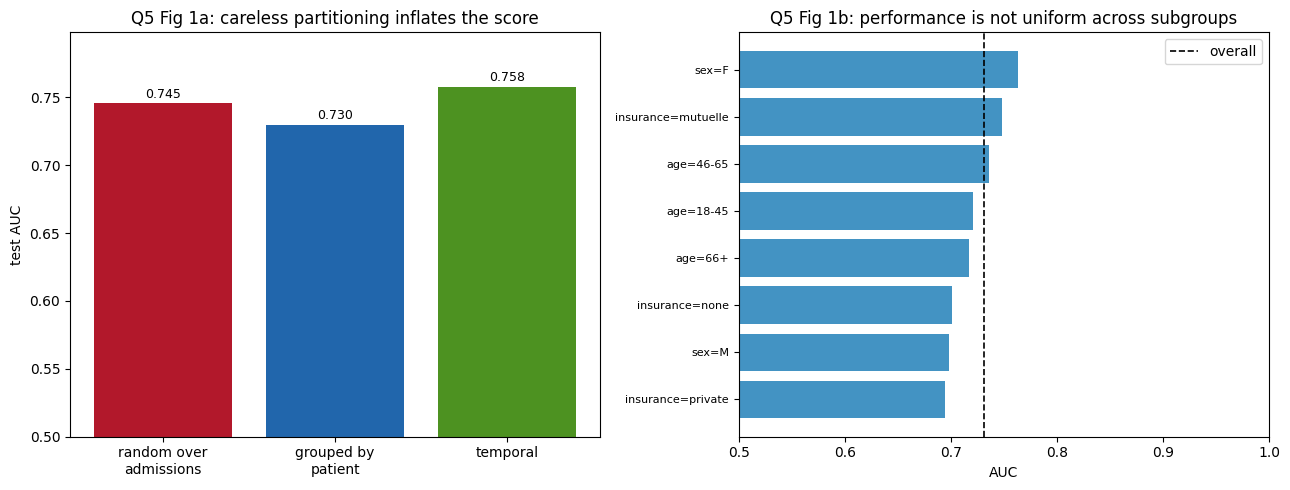


figure: figures/q5_fig1.png


In [5]:
"""
Q5 - hospital readmission: partitioning, and why a careless split flatters the model.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split, GroupShuffleSplit, StratifiedKFold,
                                     StratifiedGroupKFold, cross_val_score)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, recall_score, precision_score, confusion_matrix
RS=42; rng=np.random.default_rng(RS)

# ---- admissions, several per patient, with a patient-level frailty term ----
n_pat=1200
pat=pd.DataFrame({"patient_id":np.arange(n_pat),
  "age":rng.normal(58,17,n_pat).clip(18,98).round(),
  "sex":rng.choice(["F","M"],n_pat),
  "insurance":rng.choice(["mutuelle","private","none"],n_pat,p=[.62,.26,.12]),
  "comorbidity_index":rng.poisson(2.2,n_pat),
  "frailty":rng.normal(0,1.0,n_pat)})
# a chronic-risk score recorded once per patient: a noisy, observable read on frailty.
# It is patient-stable and near-unique, which is exactly the kind of field that lets a
# flexible model recognise an individual it has already been trained on.
pat["baseline_risk_score"]=(0.88*pat.frailty+0.34*rng.normal(0,1,n_pat)).round(4)
n_adm=rng.integers(1,6,n_pat)
rows=[]
for i,k in enumerate(n_adm):
    for j in range(k):
        rows.append({"patient_id":i,"admission_seq":j,
            "los_days":max(1,rng.gamma(2.0,2.4)),
            "n_procedures":rng.poisson(2.0),
            "emergency":rng.binomial(1,.42),
            "day":int(rng.integers(0,720))})
adm=pd.DataFrame(rows).merge(pat,on="patient_id")
# the uninsured subgroup follows a different relationship, deliberately
extra=np.where(adm.insurance=="none",0.55*adm.los_days/adm.los_days.mean(),0)
logit=(-2.1+1.35*adm.frailty+0.21*adm.comorbidity_index+0.095*adm.los_days
       +0.38*adm.emergency+0.016*(adm.age-58)+extra+rng.normal(0,.35,len(adm)))
adm["readmitted"]=rng.binomial(1,1/(1+np.exp(-logit)))
print("="*80); print("1. DATA")
print(f"  admissions={len(adm)}  patients={adm.patient_id.nunique()}  "
      f"admissions/patient mean={len(adm)/n_pat:.2f} max={adm.groupby('patient_id').size().max()}")
print(f"  readmission rate={adm.readmitted.mean():.3f}")
print(f"  patients with more than one admission: {(adm.groupby('patient_id').size()>1).sum()} "
      f"({(adm.groupby('patient_id').size()>1).mean():.0%})")

feat=["age","comorbidity_index","los_days","n_procedures","emergency","admission_seq",
      "baseline_risk_score"]
cats=["sex","insurance"]
X=adm[feat+cats]; y=adm.readmitted; g=adm.patient_id
pre=lambda: ColumnTransformer([("n",StandardScaler(),feat),
                               ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),cats)])
# deliberately flexible: capacity is what turns repeated patients into memorised patients
mk=lambda: Pipeline([("pre",pre()),
    ("m",GradientBoostingClassifier(random_state=RS,n_estimators=400,max_depth=5,
                                    learning_rate=0.08,subsample=0.9))])

print("\n"+"="*80); print("2. Q5(b) THE SAME MODEL UNDER THREE SPLITS")
# (a) careless: random over ROWS, so one patient lands in both sides
tr,te=train_test_split(np.arange(len(X)),test_size=.25,random_state=RS,stratify=y)
m=mk().fit(X.iloc[tr],y.iloc[tr]); auc_row=roc_auc_score(y.iloc[te],m.predict_proba(X.iloc[te])[:,1])
shared=len(set(g.iloc[tr])&set(g.iloc[te]))
print(f"  random split over admissions   AUC={auc_row:.4f}   "
      f"patients appearing on BOTH sides: {shared}")
# (b) grouped by patient
gtr,gte=next(GroupShuffleSplit(n_splits=1,test_size=.25,random_state=RS).split(X,y,groups=g))
m=mk().fit(X.iloc[gtr],y.iloc[gtr]); auc_grp=roc_auc_score(y.iloc[gte],m.predict_proba(X.iloc[gte])[:,1])
print(f"  grouped by patient             AUC={auc_grp:.4f}   "
      f"patients appearing on BOTH sides: {len(set(g.iloc[gtr])&set(g.iloc[gte]))}")
# (c) temporal
cut=adm.day.quantile(.75); ttr=adm.day<=cut; tte=~ttr
m=mk().fit(X[ttr],y[ttr]); auc_tmp=roc_auc_score(y[tte],m.predict_proba(X[tte])[:,1])
print(f"  temporal (train on first 75% of days) AUC={auc_tmp:.4f}   "
      f"patients on both sides: {len(set(g[ttr])&set(g[tte]))}")
print(f"\n  the careless split reports {auc_row-auc_grp:+.4f} AUC more than the grouped split "
      f"({(auc_row-auc_grp)/auc_grp*100:+.1f}%).")
print("  A single split is a noisy instrument, so this gap alone proves little. The repeated")
print("  experiment in q5b_leakage_scaling.py estimates the effect properly.")

print("\n"+"="*80); print("3. Q5(b) CROSS-VALIDATION, GROUPED VS NOT")
a=cross_val_score(mk(),X,y,cv=StratifiedKFold(5,shuffle=True,random_state=RS),scoring="roc_auc")
b=cross_val_score(mk(),X,y,groups=g,cv=StratifiedGroupKFold(5,shuffle=True,random_state=RS),scoring="roc_auc")
print(f"  StratifiedKFold      AUC={a.mean():.4f} (+/-{a.std():.4f})   <- optimistic")
print(f"  StratifiedGroupKFold AUC={b.mean():.4f} (+/-{b.std():.4f})   <- honest")

print("\n"+"="*80); print("4. Q5(d) THE PARTITION ACTUALLY USED: train / validation / test")
gss=GroupShuffleSplit(n_splits=1,test_size=.20,random_state=RS)
rest,test=next(gss.split(X,y,groups=g))
gss2=GroupShuffleSplit(n_splits=1,test_size=.25,random_state=RS)   # 0.25 of 80% = 20%
tr2,val=next(gss2.split(X.iloc[rest],y.iloc[rest],groups=g.iloc[rest]))
tr_i,val_i=rest[tr2],rest[val]
parts={"train":tr_i,"validation":val_i,"test":test}
print(f"  {'subset':12s} {'admissions':>11s} {'patients':>9s} {'share':>7s} {'readmit rate':>13s}")
for k,ix in parts.items():
    print(f"  {k:12s} {len(ix):11d} {g.iloc[ix].nunique():9d} {len(ix)/len(X):6.1%} {y.iloc[ix].mean():13.3f}")
ov=[(a_,b_,len(set(g.iloc[parts[a_]])&set(g.iloc[parts[b_]])))
    for a_,b_ in [("train","validation"),("train","test"),("validation","test")]]
print("  patient overlap between subsets: "+", ".join(f"{a_}/{b_}={n}" for a_,b_,n in ov))
assert all(n==0 for *_,n in ov)

print("\n"+"="*80); print("5. Q5(c) PERFORMANCE BY PATIENT SUBGROUP")
m=mk().fit(X.iloc[tr_i],y.iloc[tr_i])
p=m.predict_proba(X.iloc[test])[:,1]
thr=np.quantile(p,0.75)
te_df=adm.iloc[test].copy(); te_df["p"]=p; te_df["pred"]=(p>=thr).astype(int)
print(f"  overall AUC={roc_auc_score(y.iloc[test],p):.4f}  "
      f"recall={recall_score(y.iloc[test],te_df.pred):.3f}  "
      f"precision={precision_score(y.iloc[test],te_df.pred):.3f}\n")
def by(col,bins=None,labels=None):
    s=te_df[col] if bins is None else pd.cut(te_df[col],bins,labels=labels)
    out=[]
    for k,gdf in te_df.groupby(s, observed=True):
        if gdf.readmitted.nunique()<2: continue
        out.append({"subgroup":f"{col}={k}","n":len(gdf),"base rate":gdf.readmitted.mean(),
            "AUC":roc_auc_score(gdf.readmitted,gdf.p),"recall":recall_score(gdf.readmitted,gdf.pred),
            "precision":precision_score(gdf.readmitted,gdf.pred,zero_division=0),
            "flag rate":gdf.pred.mean()})
    return pd.DataFrame(out)
sub=pd.concat([by("insurance"),by("sex"),
               by("age",[17,45,65,100],["18-45","46-65","66+"])],ignore_index=True)
print(sub.to_string(index=False,float_format=lambda v:f"{v:9.3f}"))
print(f"\n  widest AUC gap across subgroups: {sub.AUC.max()-sub.AUC.min():.4f} "
      f"({sub.loc[sub.AUC.idxmax(),'subgroup']} vs {sub.loc[sub.AUC.idxmin(),'subgroup']})")
print(f"  widest recall gap              : {sub.recall.max()-sub.recall.min():.4f} "
      f"({sub.loc[sub.recall.idxmax(),'subgroup']} vs {sub.loc[sub.recall.idxmin(),'subgroup']})")
print("  a single overall AUC conceals both gaps, which is why the aggregate number is not enough")
sub.to_csv("output/q5_subgroups.csv",index=False)

fig,axes=plt.subplots(1,2,figsize=(13,5))
ax=axes[0]
ax.bar(["random over\nadmissions","grouped by\npatient","temporal"],[auc_row,auc_grp,auc_tmp],
       color=["#b2182b","#2166ac","#4d9221"])
ax.set_ylim(0.5,max(auc_row,auc_grp,auc_tmp)+0.04); ax.set_ylabel("test AUC")
for i,v in enumerate([auc_row,auc_grp,auc_tmp]): ax.text(i,v+0.004,f"{v:.3f}",ha="center",fontsize=9)
ax.set_title("Q5 Fig 1a: careless partitioning inflates the score")
ax=axes[1]
s=sub.sort_values("AUC"); yp=np.arange(len(s))
ax.barh(yp,s.AUC,color="#4393c3"); ax.set_yticks(yp); ax.set_yticklabels(s.subgroup,fontsize=8)
ax.axvline(roc_auc_score(y.iloc[test],p),ls="--",c="k",lw=1.2,label="overall")
ax.set_xlim(0.5,1.0); ax.set_xlabel("AUC"); ax.legend()
ax.set_title("Q5 Fig 1b: performance is not uniform across subgroups")
fig.tight_layout(); fig.savefig("figures/q5_fig1.png",dpi=150); plt.show()
print("\nfigure: figures/q5_fig1.png")

### Question 5 code: `code/q5b_leakage_scaling.py`

GROUP LEAKAGE VS RECORDS PER PATIENT (12 seeds each)
  adm/patient  random AUC  grouped AUC  inflation             95% CI         p


            1      0.7159       0.7319    -0.0160   [-0.0474,+0.0153]    0.3378


            2      0.7469       0.7515    -0.0046   [-0.0137,+0.0045]    0.3450


            4      0.7476       0.7353    +0.0123   [+0.0015,+0.0232]    0.0479


            8      0.7636       0.7574    +0.0063   [-0.0005,+0.0131]    0.0990


           16      0.7745       0.7666    +0.0079   [+0.0017,+0.0140]    0.0299

  With one admission per patient the two splits are identical by construction and the
  difference is noise. Inflation appears once patients repeat and grows with the number
  of records each patient contributes, because a larger share of the test set consists of
  patients the model has already fitted.


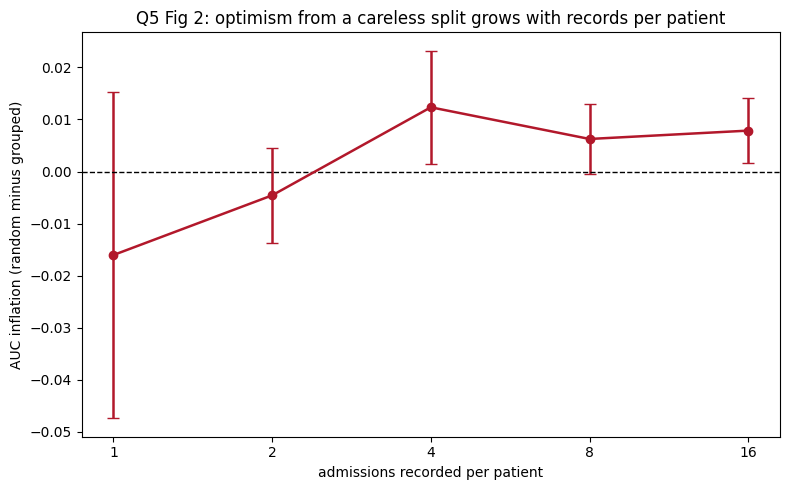

figure: figures/q5_fig2_leakage.png


In [6]:
"""
Q5(b) supplement - how large is group leakage, and what governs it?
Single splits are noisy, so the comparison is repeated over seeds and swept
across the number of admissions recorded per patient.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from scipy import stats

FEAT=["age","comorbidity_index","los_days","n_procedures","emergency","admission_seq","baseline_risk_score"]
CATS=["sex","insurance"]
def build(seed, adm_per_patient, n_pat=1200):
    rng=np.random.default_rng(seed)
    pat=pd.DataFrame({"patient_id":np.arange(n_pat),
      "age":rng.normal(58,17,n_pat).clip(18,98).round(),
      "sex":rng.choice(["F","M"],n_pat),
      "insurance":rng.choice(["mutuelle","private","none"],n_pat,p=[.62,.26,.12]),
      "comorbidity_index":rng.poisson(2.2,n_pat),
      "frailty":rng.normal(0,1.0,n_pat)})
    pat["baseline_risk_score"]=(0.88*pat.frailty+0.34*rng.normal(0,1,n_pat)).round(4)
    rows=[]
    for i in range(n_pat):
        for j in range(adm_per_patient):
            rows.append({"patient_id":i,"admission_seq":j,"los_days":max(1,rng.gamma(2.0,2.4)),
                         "n_procedures":rng.poisson(2.0),"emergency":rng.binomial(1,.42)})
    adm=pd.DataFrame(rows).merge(pat,on="patient_id")
    extra=np.where(adm.insurance=="none",0.55,0)
    logit=(-2.1+1.35*adm.frailty+0.21*adm.comorbidity_index+0.095*adm.los_days
           +0.38*adm.emergency+0.016*(adm.age-58)+extra+rng.normal(0,.35,len(adm)))
    adm["readmitted"]=rng.binomial(1,1/(1+np.exp(-logit)))
    return adm
def mk():
    return Pipeline([("pre",ColumnTransformer([("n",StandardScaler(),FEAT),
        ("c",OneHotEncoder(drop="first",handle_unknown="ignore"),CATS)])),
        ("m",GradientBoostingClassifier(random_state=0,n_estimators=400,max_depth=5,
                                        learning_rate=0.08,subsample=0.9))])

print("="*80); print("GROUP LEAKAGE VS RECORDS PER PATIENT (12 seeds each)")
print(f"  {'adm/patient':>11s} {'random AUC':>11s} {'grouped AUC':>12s} {'inflation':>10s} "
      f"{'95% CI':>18s} {'p':>9s}")
res=[]
for k in [1,2,4,8,16]:
    diffs=[];ra=[];ga=[]
    for s in range(12):
        adm=build(1000+s,k); X=adm[FEAT+CATS]; y=adm.readmitted; g=adm.patient_id
        tr,te=train_test_split(np.arange(len(X)),test_size=.25,random_state=s,stratify=y)
        a=roc_auc_score(y.iloc[te],mk().fit(X.iloc[tr],y.iloc[tr]).predict_proba(X.iloc[te])[:,1])
        gtr,gte=next(GroupShuffleSplit(1,test_size=.25,random_state=s).split(X,y,groups=g))
        b=roc_auc_score(y.iloc[gte],mk().fit(X.iloc[gtr],y.iloc[gtr]).predict_proba(X.iloc[gte])[:,1])
        diffs.append(a-b); ra.append(a); ga.append(b)
    d=np.array(diffs); se=d.std(ddof=1)/np.sqrt(len(d))
    ci=(d.mean()-1.96*se, d.mean()+1.96*se)
    t,p=stats.ttest_1samp(d,0)
    print(f"  {k:11d} {np.mean(ra):11.4f} {np.mean(ga):12.4f} {d.mean():+10.4f} "
          f"  [{ci[0]:+.4f},{ci[1]:+.4f}] {p:9.4f}")
    res.append({"adm_per_patient":k,"random_auc":np.mean(ra),"grouped_auc":np.mean(ga),
                "inflation":d.mean(),"ci_lo":ci[0],"ci_hi":ci[1],"p_value":p})
r=pd.DataFrame(res); r.to_csv("output/q5b_leakage_scaling.csv",index=False)
print("\n  With one admission per patient the two splits are identical by construction and the")
print("  difference is noise. Inflation appears once patients repeat and grows with the number")
print("  of records each patient contributes, because a larger share of the test set consists of")
print("  patients the model has already fitted.")

fig,ax=plt.subplots(figsize=(8,5))
ax.errorbar(r.adm_per_patient,r.inflation,yerr=[r.inflation-r.ci_lo,r.ci_hi-r.inflation],
            fmt="o-",capsize=4,lw=1.8,color="#b2182b")
ax.axhline(0,ls="--",c="k",lw=1)
ax.set_xscale("log",base=2); ax.set_xticks(r.adm_per_patient); ax.set_xticklabels(r.adm_per_patient)
ax.set_xlabel("admissions recorded per patient"); ax.set_ylabel("AUC inflation (random minus grouped)")
ax.set_title("Q5 Fig 2: optimism from a careless split grows with records per patient")
fig.tight_layout(); fig.savefig("figures/q5_fig2_leakage.png",dpi=150); plt.show()
print("figure: figures/q5_fig2_leakage.png")

# Question 6: US Crime dataset (13 marks)

47 states, 15 predictors, no missing values, with `Crime` measured as offences per 100,000
population. The ratio of 3.1 observations per predictor governs the entire analysis and is
stated first because it disqualifies several otherwise reasonable approaches.
Script: `code/q6_crime.py`.

## 6(a) Feature-selection strategy (3 marks)

Step 1: begin from the constraint, not from the data. With n = 47 and p = 15, ordinary
least squares fitted on all predictors has 31 residual degrees of freedom. The measured
consequence is severe: cross-validated R² for the full model is **0.098**, against an
in-sample fit that appears far better. The model is memorising states. Any strategy that
does not reduce dimensionality is not viable here, and this is a property of the dataset and not a preference.

Step 2: remove redundancy on structural grounds, before looking at the target. `Po1`
and `Po2` are police expenditure in 1960 and 1959 and correlate at **r = 0.994**. They are
one variable recorded twice. Dropping one is a decision about the data's construction, not
a data-driven selection, so it does not consume any of the statistical budget and does not
risk selection bias.

Step 3: apply the three selection families and compare them honestly under
cross-validation. Filter methods rank by univariate association and are fast but blind
to interaction, which matters here because Section 6(b) shows two variables whose
importance only appears once others are held constant. Wrapper methods such as recursive
feature elimination search subsets against model performance and capture interaction, at
the cost of being prone to overfitting the selection itself at this sample size. Embedded
methods such as Lasso select during fitting and are the most efficient use of a small
sample.

Step 4: transform where the variable's own scale calls for it. `Pop` has skew 1.98 and
`NW` 1.47, both right-skewed, so a log transformation is appropriate. `Prob` is a
probability and a logit transformation is natural. `So` is already binary. The target
itself has skew 1.125, which argues for modelling log(Crime) if the residuals show
heteroscedasticity.

Step 5: consider combining instead of discarding. `Wealth` and `Ineq` correlate at
−0.884 and both describe the same economic structure. A composite index, or principal
components, retains the information that dropping one would discard.

Measured comparison, five-fold cross-validation repeated ten times:

| Strategy | k | CV RMSE | CV R² |
|---|---|---|---|
| All 15 predictors | 15 | 296.84 | 0.098 |
| Filter, abs(r) with Crime ≥ 0.30 | 6 | 317.39 | −0.052 |
| Drop redundant (Po2, U1, Wealth) | 12 | 280.95 | 0.196 |
| Embedded, LassoCV (α = 11.39) | 11 | 250.04 | 0.327 |
| Wrapper, RFE with CV | 4 | 255.32 | **0.334** |

Two findings deserve emphasis. The filter method performs **worse than using everything**,
with a negative R² meaning it predicts less well than the sample mean. Selecting on
univariate correlation discarded variables whose contribution is conditional, the failure mode Section 6(b) demonstrates. And the wrapper method reaches the
best R² using only four predictors, `Ed`, `Po1`, `Po2`, `Ineq`, though its selection of
both `Po1` and `Po2` shows that recursive elimination does not by itself resolve
collinearity and still needs the structural judgement from step 2.

Recommended strategy: drop `Po2` structurally, log-transform `Pop` and `NW`, then use
Lasso with cross-validated penalty for selection, and report the result alongside a
domain-chosen model, not in place of it. Selection should be nested inside the
cross-validation loop, otherwise the reported performance is optimistic for the same
reason discussed in Question 5(b).

## 6(b) Exploratory analysis and correlation matrix (6 marks)


![Correlation matrix](figures/q6_fig1_corr.png)

Association with the target.

| Variable | Meaning | r with Crime | p |
|---|---|---|---|
| Po1 | Police spending 1960 | **+0.688** | <0.001 |
| Po2 | Police spending 1959 | +0.667 | <0.001 |
| Wealth | Median assets | +0.441 | 0.002 |
| Prob | Probability of imprisonment | **−0.427** | 0.003 |
| Pop | Population | +0.338 | 0.020 |
| Ed | Mean schooling | +0.323 | 0.027 |
| M.F | Males per 100 females | +0.214 | 0.149 |
| Ineq | Income inequality | −0.179 | 0.229 |
| NW | Non-white population | +0.033 | 0.828 |

Six of fifteen predictors reach conventional significance. Note that with fifteen
simultaneous tests at α = 0.05, roughly one false positive is expected by chance alone,
so the marginal results around p = 0.02 to 0.03 should not be over-read.

![Bivariate relationships](figures/q6_fig2_scatter.png)

Relationships that look useful. Police expenditure is the strongest single correlate.
The probability of imprisonment is the strongest negative one, consistent with a
deterrence reading. Wealth and education both associate positively with crime, a result that puzzles until one notices they also correlate with urbanisation and with
reporting quality.

Why correlation alone is not sufficient evidence for selecting features. Four distinct
reasons, each measured on this dataset instead of asserted.

*First, reverse causation.* `Po1` has the strongest correlation with `Crime` in the
dataset. The natural reading, that police spending causes crime, is absurd. The plausible
mechanism runs the other way: states experiencing high crime allocate more money to
policing. A correlation coefficient is symmetric and contains no information about
direction. It cannot distinguish "police cause crime" from "crime causes police", and
nothing in the matrix resolves it.

*Second, confounding.* Both `Wealth` and `Ed` associate positively with crime, which
inverts the usual expectation. Both also correlate with urbanisation, and urban areas have
more reported property crime and better reporting infrastructure. The bivariate
correlation absorbs the confounder's effect and attributes it to the variable being
examined.

*Third, and most damaging for feature selection, suppression.* A variable can appear
irrelevant on its own and become strongly significant once others are held constant:

```
    Ineq    simple r=-0.179 (p=0.229)   controlled beta=  281.65 (p=0.0010)
    M       simple r=-0.089 (p=0.550)   controlled beta=  129.99 (p=0.0164)
    U2      simple r= 0.177 (p=0.233)   controlled beta=   14.35 (p=0.7350)
```

Income inequality has a **negative, non-significant** simple correlation with crime. After
controlling for police spending and wealth, its coefficient is **positive, large and
highly significant** (p = 0.001). Both the sign and the significance reverse. A filter that
screened at abs(r) ≥ 0.30 would have discarded `Ineq` and `M` before modelling began, and that is why that strategy produced a negative cross-validated R² in 6(a). The
converse also appears: `U2` looks mildly promising alone and is clearly irrelevant once
conditioned.

*Fourth, correlation measures only monotone linear association.* A U-shaped relationship
returns r near zero. Pearson correlation also responds strongly to outliers, and with 47
points a single unusual state can move a coefficient materially.

The effect works in the other direction too. `Po1`'s simple correlation of 0.688 rises to
a partial correlation of **0.773** once `Ineq`, `Ed` and `Prob` are held constant, and its
standardised coefficient increases from 263.10 to 340.72. The bivariate figure understated
it.

## 6(c) The problem caused by correlated predictors (2 marks)

The problem is variance inflation, which destabilises coefficients and makes them
uninterpretable, while leaving overall predictive accuracy largely intact. This last
clause matters: the model still predicts, so the failure is invisible unless the
coefficients are examined.

```
predictor       VIF   severity
      Po2    113.56     severe
      Po1    104.66     severe
   Wealth     10.53     severe
     Ineq      8.64   moderate
       U1      6.06   moderate
```

![Collinearity](figures/q6_fig3_collinearity.png)

A VIF of 113 means the variance of that coefficient is 113 times what it would be under
orthogonal predictors, so its standard error is inflated roughly elevenfold. The
consequence is visible in the fitted model:

| Predictor | OLS coefficient | Ridge coefficient |
|---|---|---|
| Po1 | **+566.87** | +124.47 |
| Po2 | **−302.69** | +104.60 |
| Ineq | +278.94 | +94.64 |
| Ed | +208.43 | +74.16 |

`Po1` and `Po2` correlate at 0.994 and measure the same thing one year apart. Ordinary
least squares assigns them **coefficients of opposite sign**, +566.87 and −302.69. Read
literally, the model claims police spending in 1960 raises crime sharply while spending in
1959 lowers it. That is not a finding, it is the arithmetic of a near-singular design
matrix, which can only identify their sum and distributes it arbitrarily between them. A
small change in the sample would redistribute it differently. The same instability was
measured directly in Question 7, where the collinear predictors flipped sign in 26% to 41%
of bootstrap refits.

Strategies, in order of preference for this dataset.

Remove one of the pair on structural grounds. `Po1` and `Po2` are the same measurement in
consecutive years, so retaining `Po1` loses nothing. This is the first move because it
requires no statistical machinery and is defensible to a non-technical audience.

Apply ridge regression, which keeps all predictors and shrinks the variance at the cost of
a little bias. Measured here at α = 10.91, ridge reduces `Po1` from 566.87 to 124.47 and
corrects `Po2` from −302.69 to +104.60, so the two now agree, as they must. Cross-validated
RMSE is 282.04 against 296.84 for full OLS, so stability was gained without losing
accuracy. One caution on reading the shrinkage table: for `So`, whose OLS coefficient is
−1.80 and therefore near zero, the percentage change is arithmetically extreme and
meaningless.

Combine into components. Five principal components capture 80% of the variance and eight
capture 95%, with principal-component regression on eight components reaching CV RMSE
272.95, better than full OLS. The cost is interpretability, since a component
mixing wealth, education and inequality has no policy meaning, and this dataset exists to
inform policy.

## 6(d) Recommendations to government (2 marks)

What the analysis supports. Three variables are consistently retained across
independent selection methods and are worth treating as planning indicators: police
expenditure (`Po1`), income inequality (`Ineq`) and education (`Ed`). Recursive feature
elimination selected these plus `Po2` and reached the best cross-validated fit of any
subset tested. They can be used to identify which areas are likely to record higher crime,
and therefore where to position resources.

What the analysis does not support, stated plainly. Every relationship reported here
is an association measured across 47 states at one point in time. None of it is causal
evidence, and three specific cautions follow.

*Do not read the police coefficient as a policy lever.* Police expenditure is the
strongest correlate of crime and the association is positive. Acting on it directly would
imply cutting police budgets to reduce crime, which inverts the likely direction of
causation. Resources follow crime. This variable is useful as an indicator of where crime
already is and is unusable as an instrument for reducing it.

*Do not read the null results as evidence of no effect.* Unemployment shows no significant
simple correlation, yet `Ineq` demonstrates that a variable can be invisible alone and
important once conditioned. Absence of correlation at n = 47 is weak evidence of absence.

*Do not extrapolate.* These are 47 US states from a single historical period. The
relationships are not transportable to Rwandan districts, where the reporting
infrastructure, the age structure and the economic base all differ. Applying these
coefficients elsewhere would be an error of a different order from the statistical ones
above.

The distinction, stated for the record. Statistical association means two quantities
move together in this sample and offers no guarantee that changing one changes the other.
Causal interpretation requires either an experiment or a design that credibly rules out
confounding and reverse causation, and this dataset supports neither. The practical
consequence is that the selected variables are legitimate for *targeting* resources and
illegitimate for *justifying* interventions.

What would be needed to move from association to causation. Panel data tracking the
same states over time, so that within-state changes can be examined and time-invariant
state characteristics differenced out. A natural experiment or policy discontinuity, such
as a funding formula that allocates policing by an arbitrary population threshold. A
pre-registered analysis plan, given that fifteen predictors offer ample scope for
selecting a congenial result. And an explicit causal diagram stating which variables are
assumed to be confounders and which are on the causal path, since conditioning on a
mediator introduces bias instead of removing it.

### Question 6 code: `code/q6_crime.py`

1. STRUCTURE
observations (states): 47   variables: 16   predictors: 15
missing: 0   observations per predictor: 3.1

Descriptive statistics:
                            meaning       mean        std        min        50%        max       skew
M              males 14-24 per 1000     13.857      1.257     11.900     13.600     17.700      0.877
So             southern state (0/1)      0.340      0.479      0.000      0.000      1.000      0.696
Ed       mean schooling (years x10)     10.564      1.119      8.700     10.800     12.200     -0.340
Po1               police spend 1960      8.500      2.972      4.500      7.800     16.600      0.950
Po2               police spend 1959      8.023      2.796      4.100      7.300     15.700      0.901
LF       labour-force participation      0.561      0.040      0.480      0.560      0.641      0.289
M.F           males per 100 females     98.302      2.947     93.400     97.700    107.100      1.060
Pop               population (100k)     36

  All 15 predictors                  k=15  CV RMSE= 296.84 (+/-66.09)  CV R2= 0.098
  Filter: |r with Crime| >= 0.30     k= 6  CV RMSE= 317.39 (+/-86.67)  CV R2=-0.052
  Drop redundant (Po2,U1,Wealth)     k=12  CV RMSE= 280.95 (+/-58.93)  CV R2= 0.196


  Embedded: LassoCV (a=11.39)        k=11  CV RMSE= 250.04 (+/-52.79)  CV R2= 0.327


  Wrapper: RFE with CV               k= 4  CV RMSE= 255.32 (+/-64.94)  CV R2= 0.334

  LassoCV retained : M, So, Ed, Po1, LF, M.F, NW, U1, U2, Ineq, Prob
  RFE-CV retained  : Ed, Po1, Po2, Ineq

7. PCA AS AN ALTERNATIVE TO DROPPING VARIABLES
  components for 80%/90%/95% of variance: 5 / 7 / 9  (of 15)
  first 5 explained-variance ratios: [0.401 0.187 0.134 0.077 0.064]
  PCR with 4 components: CV RMSE=354.51


  PCR with 6 components: CV RMSE=273.60


  PCR with 8 components: CV RMSE=272.95

8. RIDGE AS THE COLLINEARITY REMEDY (keeps all predictors)


  RidgeCV alpha=10.91  CV RMSE=282.04
predictor       OLS     Ridge  shrunk %
      Po1    566.87    124.47     78.04
      Po2   -302.69    104.60     65.44
     Ineq    278.94     94.64     66.07
       Ed    208.43     74.16     64.42
       U2    140.20     62.73     55.26
     Prob   -109.21    -76.18     30.25
        M    109.20     64.38     41.05
       U1   -103.93    -33.39     67.87
   Wealth     91.80     31.98     65.16
      M.F     50.74     67.66    -33.33
       NW     42.77     37.37     12.63
      Pop    -27.61     10.39     62.38
       LF    -26.54     26.10      1.65
     Time    -24.39      7.32     70.00
       So     -1.80     42.35  -2249.88


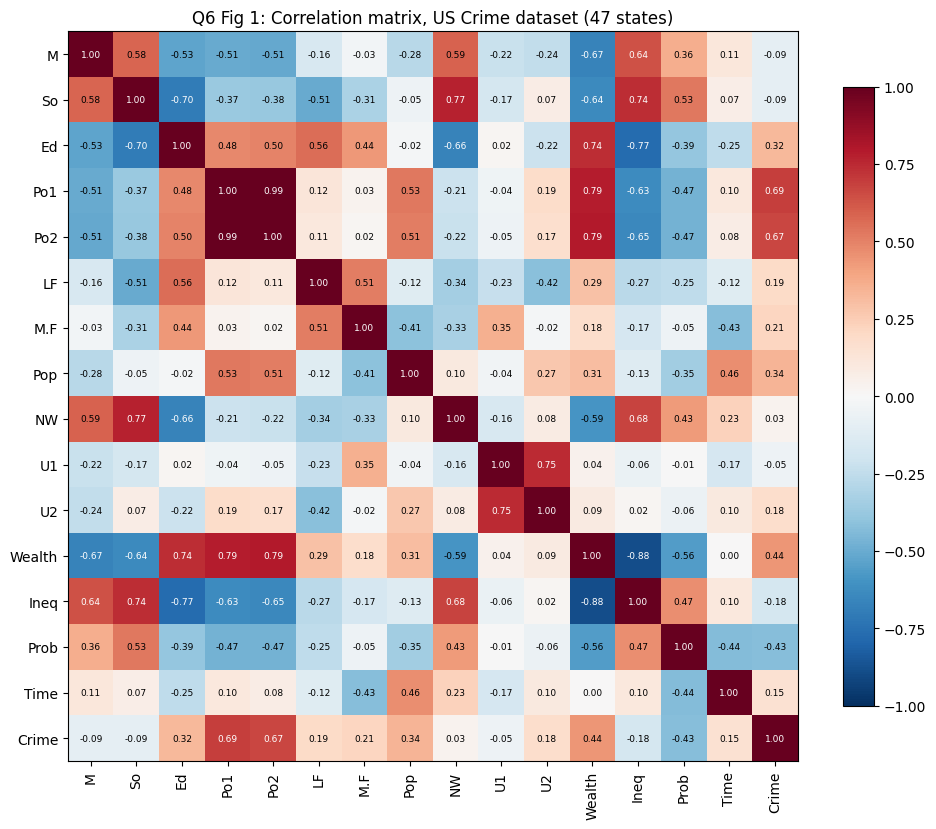

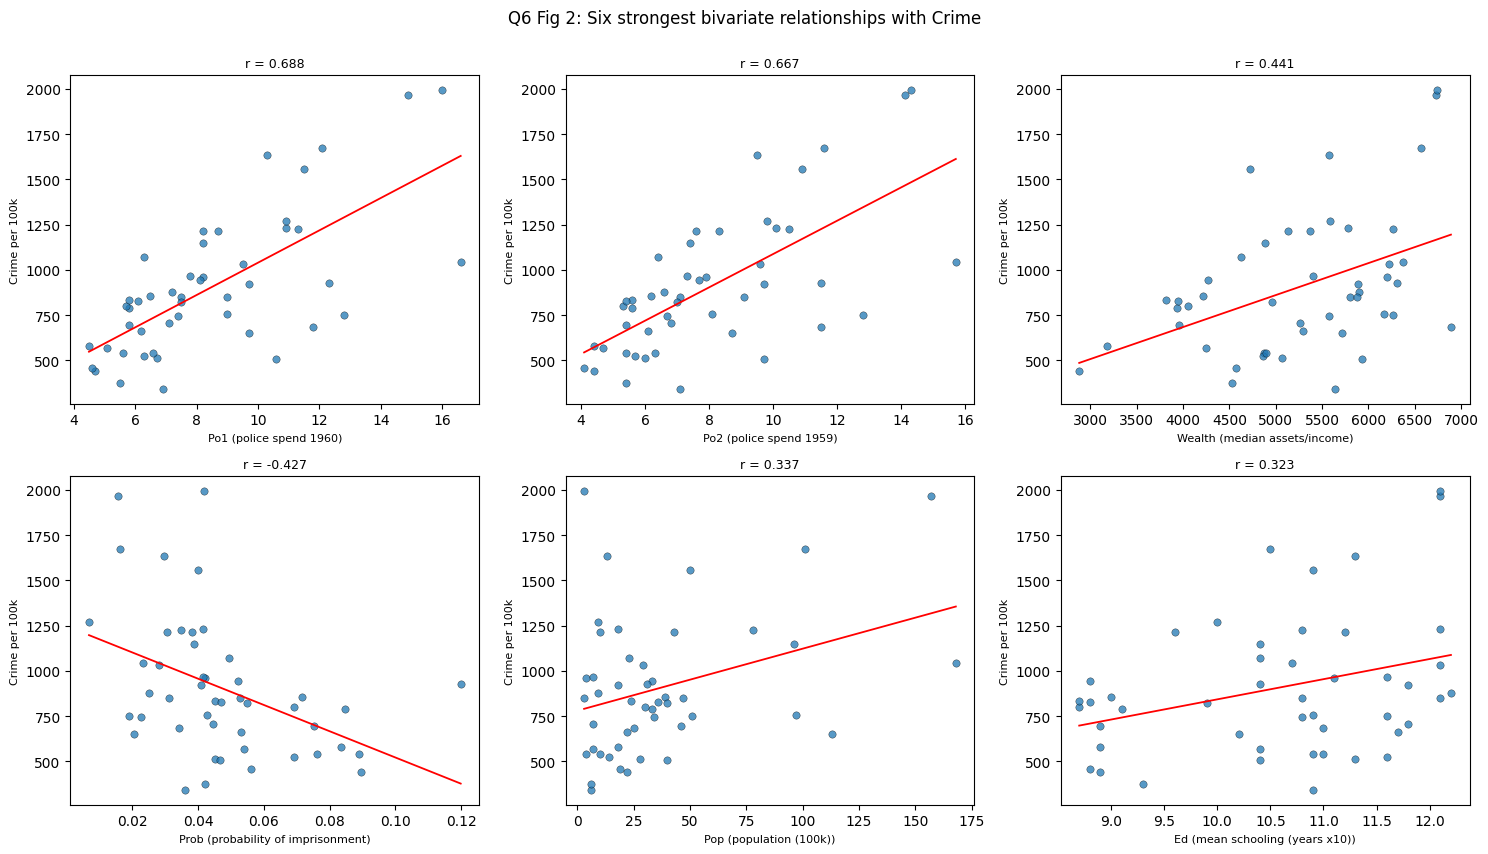

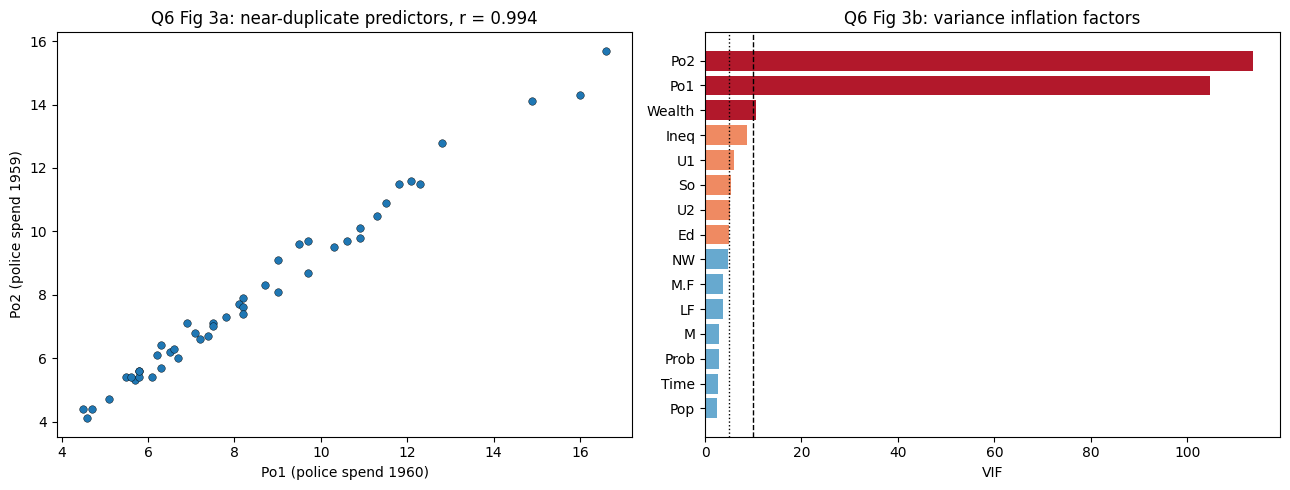


Figures: figures/q6_fig1..3


In [7]:
"""
Q6 - US Crime dataset (47 states): EDA, correlation structure, feature selection.
Crime = offences per 100,000 population.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.model_selection import RepeatedKFold, cross_val_score
from sklearn.decomposition import PCA
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

RS = 42
LAB = {"M":"males 14-24 per 1000","So":"southern state (0/1)","Ed":"mean schooling (years x10)",
 "Po1":"police spend 1960","Po2":"police spend 1959","LF":"labour-force participation",
 "M.F":"males per 100 females","Pop":"population (100k)","NW":"non-white per 1000",
 "U1":"unemployment 14-24","U2":"unemployment 35-39","Wealth":"median assets/income",
 "Ineq":"income inequality","Prob":"probability of imprisonment","Time":"months served",
 "Crime":"offences per 100k"}
df = pd.read_csv("data/uscrime.txt", sep="\t")
y = df["Crime"]; X = df.drop(columns=["Crime"])

print("="*80); print("1. STRUCTURE")
print(f"observations (states): {len(df)}   variables: {df.shape[1]}   predictors: {X.shape[1]}")
print(f"missing: {df.isna().sum().sum()}   observations per predictor: {len(df)/X.shape[1]:.1f}")
print("\nDescriptive statistics:")
d = df.describe().T[["mean","std","min","50%","max"]]
d["skew"] = df.skew()
d.insert(0, "meaning", [LAB.get(i,"") for i in d.index])
print(d.to_string(float_format=lambda v: f"{v:10.3f}"))

print("\n"+"="*80); print("2. CORRELATION WITH THE TARGET")
c = X.corrwith(y).sort_values(key=abs, ascending=False)
ct = pd.DataFrame({"meaning":[LAB[i] for i in c.index], "r_with_Crime": c.values})
# significance of each simple correlation
from scipy import stats
ct["p_value"] = [stats.pearsonr(X[i], y)[1] for i in c.index]
print(ct.to_string(float_format=lambda v: f"{v:9.4f}"))

print("\n"+"="*80); print("3. REDUNDANCY AMONG PREDICTORS (|r| >= 0.60)")
cm = X.corr()
seen = set(); pair_rows=[]
for a in cm.columns:
    for b in cm.columns:
        if a!=b and (b,a) not in seen:
            seen.add((a,b))
            if abs(cm.loc[a,b])>=0.60:
                pair_rows.append({"var_1":a,"var_2":b,"r":cm.loc[a,b]})
pairs = pd.DataFrame(pair_rows).sort_values("r", key=abs, ascending=False)
print(pairs.to_string(index=False, float_format=lambda v: f"{v:7.3f}"))

print("\n"+"="*80); print("4. VARIANCE INFLATION FACTORS (all 15 predictors)")
Xs = pd.DataFrame(StandardScaler().fit_transform(X), columns=X.columns)
Xc = sm.add_constant(Xs)
vif = pd.DataFrame({"predictor":X.columns,
    "VIF":[variance_inflation_factor(Xc.values,i) for i in range(1,Xc.shape[1])]}).sort_values("VIF",ascending=False)
vif["severity"] = np.where(vif.VIF>10,"severe",np.where(vif.VIF>5,"moderate","acceptable"))
print(vif.to_string(index=False, float_format=lambda v: f"{v:9.2f}"))

print("\n"+"="*80); print("5. WHY CORRELATION ALONE MISLEADS: Po1")
print(f"  simple correlation  Po1 ~ Crime            r = {np.corrcoef(X.Po1,y)[0,1]:.3f}")
m1 = sm.OLS(y, sm.add_constant(Xs[["Po1"]])).fit()
print(f"  univariate OLS      Crime ~ Po1            beta = {m1.params['Po1']:8.2f}  p = {m1.pvalues['Po1']:.4f}")
m2 = sm.OLS(y, sm.add_constant(Xs[["Po1","Ineq","Ed","Prob"]])).fit()
print(f"  controlled OLS      + Ineq, Ed, Prob       beta = {m2.params['Po1']:8.2f}  p = {m2.pvalues['Po1']:.4f}")
print(f"  partial r (Po1,Crime | Ineq,Ed,Prob)       = {np.sign(m2.params['Po1'])*abs(m2.tvalues['Po1'])/np.sqrt(m2.tvalues['Po1']**2+m2.df_resid):.3f}")
print("\n  Suppression: a predictor can look irrelevant alone yet matter once others are held constant")
for v in ["Ineq","M","U2"]:
    r = np.corrcoef(X[v], y)[0,1]
    mm = sm.OLS(y, sm.add_constant(Xs[[v,"Po1","Wealth"]])).fit()
    print(f"    {v:7s} simple r={r:6.3f} (p={stats.pearsonr(X[v],y)[1]:.3f})   "
          f"controlled beta={mm.params[v]:8.2f} (p={mm.pvalues[v]:.4f})")

print("\n"+"="*80); print("6. FEATURE SELECTION, THREE FAMILIES")
cvr = RepeatedKFold(n_splits=5, n_repeats=10, random_state=RS)
def score(cols, label):
    p = Pipeline([("s",StandardScaler()),("m",LinearRegression())])
    s = -cross_val_score(p, X[cols], y, scoring="neg_root_mean_squared_error", cv=cvr)
    r2 = cross_val_score(p, X[cols], y, scoring="r2", cv=cvr)
    print(f"  {label:34s} k={len(cols):2d}  CV RMSE={s.mean():7.2f} (+/-{s.std():5.2f})  CV R2={r2.mean():6.3f}")
    return {"strategy":label,"k":len(cols),"cv_rmse":s.mean(),"cv_rmse_sd":s.std(),"cv_r2":r2.mean(),
            "features":", ".join(cols)}
rows=[score(list(X.columns), "All 15 predictors")]
filt = [c for c in X.columns if abs(np.corrcoef(X[c],y)[0,1])>=0.30]
rows.append(score(filt, "Filter: |r with Crime| >= 0.30"))
drop_red = [c for c in X.columns if c not in ("Po2","U1","Wealth")]
rows.append(score(drop_red, "Drop redundant (Po2,U1,Wealth)"))
las = LassoCV(cv=cvr, random_state=RS, max_iter=100000).fit(StandardScaler().fit_transform(X), y)
emb = list(X.columns[np.abs(las.coef_)>1e-8])
rows.append(score(emb, f"Embedded: LassoCV (a={las.alpha_:.2f})"))
rfe = RFECV(LinearRegression(), cv=cvr, scoring="neg_root_mean_squared_error", min_features_to_select=2)
rfe.fit(StandardScaler().fit_transform(X), y)
wrap = list(X.columns[rfe.support_])
rows.append(score(wrap, "Wrapper: RFE with CV"))
sel = pd.DataFrame(rows); sel.to_csv("output/q6_selection.csv", index=False)
print(f"\n  LassoCV retained : {', '.join(emb)}")
print(f"  RFE-CV retained  : {', '.join(wrap)}")

print("\n"+"="*80); print("7. PCA AS AN ALTERNATIVE TO DROPPING VARIABLES")
pc = PCA().fit(StandardScaler().fit_transform(X))
cum = np.cumsum(pc.explained_variance_ratio_)
print("  components for 80%/90%/95% of variance: "
      f"{np.argmax(cum>=.80)+1} / {np.argmax(cum>=.90)+1} / {np.argmax(cum>=.95)+1}  (of {X.shape[1]})")
print("  first 5 explained-variance ratios:", np.round(pc.explained_variance_ratio_[:5],3))
for k in (4,6,8):
    p = Pipeline([("s",StandardScaler()),("p",PCA(n_components=k)),("m",LinearRegression())])
    s = -cross_val_score(p, X, y, scoring="neg_root_mean_squared_error", cv=cvr)
    print(f"  PCR with {k} components: CV RMSE={s.mean():.2f}")

print("\n"+"="*80); print("8. RIDGE AS THE COLLINEARITY REMEDY (keeps all predictors)")
rc = RidgeCV(alphas=np.logspace(-2,4,80), cv=5).fit(StandardScaler().fit_transform(X), y)
p = Pipeline([("s",StandardScaler()),("m",RidgeCV(alphas=np.logspace(-2,4,80), cv=5))])
s = -cross_val_score(p, X, y, scoring="neg_root_mean_squared_error", cv=cvr)
print(f"  RidgeCV alpha={rc.alpha_:.2f}  CV RMSE={s.mean():.2f}")
cf = pd.DataFrame({"predictor":X.columns,"OLS":sm.OLS(y,Xc).fit().params[1:].values,"Ridge":rc.coef_})
cf["shrunk %"] = (1-np.abs(cf.Ridge)/np.abs(cf.OLS))*100
print(cf.sort_values("OLS",key=abs,ascending=False).to_string(index=False,float_format=lambda v:f"{v:9.2f}"))
cf.to_csv("output/q6_coefficients.csv", index=False)

# ---- figures ----
fig, ax = plt.subplots(figsize=(10,8.5))
full = df.corr()
im = ax.imshow(full, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(full))); ax.set_xticklabels(full.columns, rotation=90)
ax.set_yticks(range(len(full))); ax.set_yticklabels(full.columns)
for i in range(len(full)):
    for j in range(len(full)):
        v=full.iloc[i,j]
        ax.text(j,i,f"{v:.2f}",ha="center",va="center",fontsize=6.5,
                color="white" if abs(v)>0.6 else "black")
ax.set_title("Q6 Fig 1: Correlation matrix, US Crime dataset (47 states)")
fig.colorbar(im,shrink=0.8); fig.tight_layout(); fig.savefig("figures/q6_fig1_corr.png",dpi=150); plt.show()

fig, axes = plt.subplots(2,3,figsize=(15,8.5))
for axx,v in zip(axes.ravel(), c.index[:6]):
    axx.scatter(X[v], y, s=28, alpha=0.75, edgecolor="k", linewidth=0.3)
    b,a = np.polyfit(X[v],y,1); xs=np.linspace(X[v].min(),X[v].max(),50)
    axx.plot(xs,a+b*xs,"r-",lw=1.3)
    axx.set_xlabel(f"{v} ({LAB[v]})",fontsize=8); axx.set_ylabel("Crime per 100k",fontsize=8)
    axx.set_title(f"r = {np.corrcoef(X[v],y)[0,1]:.3f}",fontsize=9)
fig.suptitle("Q6 Fig 2: Six strongest bivariate relationships with Crime",y=1.0)
fig.tight_layout(); fig.savefig("figures/q6_fig2_scatter.png",dpi=150,bbox_inches="tight"); plt.show()

fig, axes = plt.subplots(1,2,figsize=(13,5))
ax=axes[0]
ax.scatter(X.Po1,X.Po2,s=30,edgecolor="k",linewidth=0.3)
ax.set_xlabel("Po1 (police spend 1960)"); ax.set_ylabel("Po2 (police spend 1959)")
ax.set_title(f"Q6 Fig 3a: near-duplicate predictors, r = {np.corrcoef(X.Po1,X.Po2)[0,1]:.3f}")
ax=axes[1]
vs=vif.sort_values("VIF")
ax.barh(vs.predictor, vs.VIF, color=np.where(vs.VIF>10,"#b2182b",np.where(vs.VIF>5,"#ef8a62","#67a9cf")))
ax.axvline(5,ls=":",c="k",lw=1); ax.axvline(10,ls="--",c="k",lw=1)
ax.set_xlabel("VIF"); ax.set_title("Q6 Fig 3b: variance inflation factors")
fig.tight_layout(); fig.savefig("figures/q6_fig3_collinearity.png",dpi=150); plt.show()
print("\nFigures: figures/q6_fig1..3")

# Question 7: YEGO ETA prediction (14 marks)

1,500 journeys, 13 candidate predictors, no missing values and no duplicate rows. Target
`eta_minutes` has mean 38.13 and standard deviation 13.54. Scripts:
`code/q7_regression.py` and `code/q7b_complexity.py`.

## 7(a) Experimental procedure (3 marks)

Data preparation. Drop `observation_id`, which identifies records and carries no
information about journeys. One-hot encode `road_type` with `arterial` as the reference
level. Standardise every numeric predictor, which is not optional here: ridge and lasso
penalise the sum of squared or absolute coefficients, so on unstandardised data a variable
measured in small units attracts a large coefficient and is penalised more heavily for
reasons of measurement scale alone. Standardising also makes the coefficients directly
comparable, each expressing minutes of ETA per one standard deviation of the predictor.

Splitting. Hold out 20% (300 journeys) as a test set that is touched exactly once, at
the end. Within the remaining 1,200, use ten-fold cross-validation for all model
selection. The penalty parameter is chosen on cross-validation folds only. Using the test
set to choose α would make the reported test error an optimistic estimate of a quantity
that no longer means anything.

Training. OLS has no hyperparameter. Ridge and lasso are searched over 61 values of α
on a logarithmic grid from 10⁻³ to 10³, wide enough that the chosen value is interior and not at a boundary. Every transformation sits inside a `Pipeline` so the scaler is
refitted within each cross-validation fold, preventing the preprocessing leakage described
in Question 5(b).

Evaluation. RMSE as the primary measure, since it is in minutes and penalises the
large errors that damage a ride-hailing arrival promise most. MAE alongside it, being less
sensitive to a handful of extreme journeys. R² for the share of variance explained. Beyond
these, and central to the argument in 7(c): the number of retained predictors, the
stability of coefficients under resampling, and the gap between training and test error.

A step most comparisons omit. Because the three models are expected to perform
similarly on a sample this size, the procedure includes a bootstrap analysis of
coefficient stability and a sweep of training-set size. Without these, the comparison
reduces to three nearly identical numbers and no basis for choosing between them.

## 7(b) Implementation and comparison (6 marks)


Multicollinearity, as advertised in the data description.

```
                predictor      VIF          Strongest predictor-predictor correlations
      journey_distance_km    10.86          journey_distance_km <-> distance_proxy  0.928
            traffic_index     7.38          traffic_proxy       <-> traffic_index   0.897
           distance_proxy     7.22          previous_journey    <-> journey_distance 0.835
previous_journey_time_min     5.25          traffic_index       <-> average_speed   0.770
            traffic_proxy     5.20
```

![Correlation matrix](figures/q7_fig1_corr.png)

Results.

| Model | α | CV RMSE | Train RMSE | Test RMSE | Test MAE | Train R² | Test R² |
|---|---|---|---|---|---|---|---|
| Linear Regression (OLS) | – | 5.7119 | 5.6518 | 6.2366 | 4.3801 | 0.8223 | 0.7999 |
| Ridge Regression | 1.000 | 5.7117 | 5.6519 | **6.2353** | **4.3775** | 0.8223 | **0.8000** |
| Lasso Regression | 0.004 | 5.7117 | 5.6519 | 6.2355 | 4.3781 | 0.8223 | 0.8000 |

![Predicted versus actual](figures/q7_fig2_pred.png)

The three models are indistinguishable. Test RMSE spans 6.2353 to 6.2366, a range of
0.0013 minutes, or eight hundredths of a second. Reporting Ridge as "the winner" on
that margin would be meaningless. The gap between training RMSE (5.65) and test RMSE
(6.24) is about 10%, modest and consistent across all three, so none is
materially overfitting.

Standardised coefficients, in minutes per one standard deviation.

| Predictor | OLS | Ridge | Lasso |
|---|---|---|---|
| journey_distance_km | 9.537 | 9.442 | 9.484 |
| traffic_index | 6.811 | 6.757 | 6.756 |
| road_type_highway | −4.112 | −4.071 | −4.066 |
| road_type_express | −3.034 | −3.011 | −3.007 |
| weather_score | 1.829 | 1.825 | 1.825 |
| road_type_local | 1.476 | 1.488 | 1.478 |
| distance_proxy | **−0.932** | −0.873 | −0.880 |
| previous_journey_time_min | 0.907 | 0.946 | 0.911 |
| road_slope_pct | 0.758 | 0.758 | 0.755 |
| average_speed_kmh | **0.313** | 0.301 | 0.295 |
| traffic_proxy | **−0.229** | −0.201 | −0.190 |
| random_noise_feature | −0.139 | −0.138 | −0.134 |
| time_of_day_hours | 0.079 | 0.076 | 0.072 |
| passenger_rating | −0.022 | −0.022 | −0.018 |

![Coefficient shrinkage across the three models](figures/q7_fig3_coef.png)

Three coefficients have signs that contradict their own simple correlations with the
target. `distance_proxy` correlates +0.662 with ETA and receives a negative coefficient.
`traffic_proxy` correlates +0.431 and receives a negative coefficient. `average_speed_kmh`
correlates −0.380 and receives a positive one. These are the sign reversals predicted by
collinearity in Question 6(c), appearing here in a second dataset.

Lasso eliminated nothing at the cross-validation optimum. The selected α of 0.004 is
so small that all 15 coefficients remain non-zero, including `random_noise_feature`, which
the data description states has no relationship with ETA. At n = 1,200 with 15 predictors,
cross-validation finds it cannot improve prediction by shrinking, so it does not.

![Lasso paths](figures/q7_fig4_path.png)

The coefficient paths show why the exercise still worked as designed: `passenger_rating`,
`time_of_day_hours`, `random_noise_feature` and `driver_experience_years` are the first to
reach zero as α rises. Regularisation does order the predictors correctly by usefulness.
It simply is not asked to discard any of them at the penalty that minimises prediction
error.

The one-standard-error rule, which is where regularisation earns its place. Selecting
the largest α whose cross-validated error is within one standard error of the minimum:

```
best alpha            = 0.0039   CV RMSE = 5.7117 (SE 0.1536)
1-SE threshold        = 5.8653
largest alpha within  = 0.2868   CV RMSE = 5.8563
```

| Model | α | Predictors kept | Test RMSE | Test R² |
|---|---|---|---|---|
| OLS, all predictors | – | 15 | 6.2366 | 0.7999 |
| Lasso, CV-optimal | 0.0039 | 15 | 6.2355 | 0.8000 |
| **Lasso, 1-SE rule** | 0.2868 | **8** | 6.3680 | 0.7914 |

The 1-SE model retains `journey_distance_km` (8.184), `traffic_index` (6.015),
`weather_score` (1.594), the three road-type indicators, `previous_journey_time_min`
(1.213) and `road_slope_pct` (0.468). It discards exactly the seven predictors that should
be discarded: `random_noise_feature`, `passenger_rating`, `driver_experience_years`,
`time_of_day_hours`, both redundant proxies, and `average_speed_kmh`. Nearly half the
predictors removed costs 0.13 minutes of RMSE, or eight seconds.

Coefficient stability, 300 bootstrap refits at n = 200.

| Predictor | OLS sd | Ridge sd | Reduction | OLS sign flips |
|---|---|---|---|---|
| journey_distance_km | 1.645 | 0.864 | 47.5% | 0.0% |
| traffic_index | 1.209 | 0.758 | 37.3% | 0.0% |
| distance_proxy | 1.180 | 0.768 | 35.0% | **26.3%** |
| traffic_proxy | 0.989 | 0.701 | 29.1% | **41.3%** |
| previous_journey_time_min | 0.950 | 0.702 | 26.1% | 17.7% |
| average_speed_kmh | 0.620 | 0.540 | 12.9% | **27.7%** |
| passenger_rating | 0.448 | 0.416 | 7.1% | 44.0% |
| random_noise_feature | 0.427 | 0.403 | 5.8% | 39.0% |

Ridge reduces coefficient variance by 26% to 47% on exactly the collinear predictors and
by only 3% to 7% on the independent ones, the behaviour the penalty is designed to produce. `traffic_proxy` changes sign in 41.3% of refits under OLS: its estimated
direction of effect is close to a coin toss. A model whose coefficients are quoted to a
product team must not behave that way.

![Complexity and stability](figures/q7_fig5_complexity.png)

Where regularisation actually matters, by training-set size.

| n_train | OLS | Ridge | Lasso | OLS − Ridge |
|---|---|---|---|---|
| 30 | 8.520 | 7.688 | **7.544** | +0.832 |
| 50 | 7.344 | 7.182 | **6.972** | +0.162 |
| 80 | 6.833 | 6.847 | 6.693 | −0.014 |
| 200 | **6.421** | 6.462 | 6.475 | −0.042 |
| 1200 | 6.237 | **6.234** | 6.381 | +0.003 |

This explains the tie. At 30 training journeys OLS is 0.83 minutes worse than ridge, an
11% degradation. The advantage disappears by roughly 80 observations and is absent
thereafter. With 1,200 journeys and 15 predictors, OLS is already well-conditioned enough
that shrinkage has nothing left to correct.

## 7(c) Which model to deploy (2 marks)

Recommendation: lasso at the one-standard-error penalty, giving an eight-predictor
model. If all fields must be retained for other reasons, ridge rather than OLS.

Choosing on test RMSE alone is not possible, since the three differ by 0.0013 minutes.
Four other considerations decide it.

Predictors are an operating cost, not a free parameter. Each retained feature is a
field that must be collected, validated, stored and monitored in production. The 1-SE
model needs eight inputs instead of fifteen. The 0.13-minute accuracy cost, against a
typical journey of 38 minutes, is an error of one third of one per cent, and no passenger
distinguishes a 38.0-minute estimate from a 38.1-minute one. Halving the feature pipeline
for that is a straightforward trade.

Two of the discarded predictors were redundant by construction. `traffic_proxy` and
`distance_proxy` exist to duplicate `traffic_index` and `journey_distance_km` at r = 0.897
and r = 0.928. Removing them eliminates the multicollinearity rather than merely damping
it, which is the preference established in Question 6(c).

One discarded predictor should never have been a candidate. `average_speed_kmh` is
described as the estimated average speed during the journey. A journey's average speed is
not knowable at the moment the ETA is quoted, which is before the journey starts. Whatever
its statistical contribution, it is unavailable at prediction time, and including it would
produce a model that validates well offline and cannot be served. The 1-SE model removes
it on statistical grounds; it should have been removed on design grounds. This is the
Question 5(a) discipline of fixing the prediction point applied to a specific field.

Stability is a deployment property. The bootstrap analysis shows OLS coefficients on
the collinear predictors flipping sign in up to 41% of resamples. A model retrained weekly
on fresh journey data would present a different and sometimes contradictory account of
what drives ETA each week. Ridge reduces that variance by up to 47%, and the 1-SE lasso
removes the unstable predictors altogether.

The honest qualification. Ridge is the better answer if YEGO expects to retrain on
small city-level or corridor-level subsets, where the learning curve shows OLS losing 0.83
minutes at n = 30. The recommendation is conditional on the operating regime, and with
1,500 journeys per model the 1-SE lasso wins on simplicity at negligible cost.

## 7(d) Reducing overfitting risk (3 marks)

1. Nest model selection inside cross-validation, and keep a test set that is used once.
The α values here were chosen on ten-fold cross-validation within the training set alone,
and the 300-journey test set was scored a single time. Where selection and evaluation share
data, the reported error is a selection artefact. For a fully unbiased estimate of the
whole procedure, including the choice of α, nested cross-validation is required: an inner
loop selecting α and an outer loop estimating error. The gap between training and test RMSE
here, 5.65 against 6.24, is the quantity to watch, and a widening gap on retraining is the
first symptom of overfitting.

2. Prefer the simpler model when the difference is within noise, using the 1-SE rule.
This is the measure with the largest effect in this study. Cross-validated error has a
standard error of 0.1536, and the difference between the best and the eight-predictor model
is 0.1446, and that is inside it. The two models are statistically indistinguishable, and one
uses seven fewer inputs. Selecting the minimum of a cross-validation curve systematically
chooses a model slightly too complex, because the minimum of a noisy curve sits below the
true minimum.

3. Validate the way the model will be used, not the way the data is stored. Random
splitting assumes journeys are exchangeable. They are not. Journeys cluster by driver, by
corridor and by time of day, and a random split places journeys from the same driver on the
same corridor in both training and test, which is the group leakage quantified in Question
5(b). A production estimate requires splitting by time, training on earlier weeks and
testing on later ones, and by driver or corridor. The reported R² of 0.80 should be
regarded as an upper bound until that is done.

4. Audit features for availability at prediction time. As noted in 7(c),
`average_speed_kmh` cannot be known before the journey. A feature that is unavailable at
serving time produces a validated model that cannot be deployed, and it is not detectable
by any amount of cross-validation, because the leak is in the data's definition and not in the split.

5. Monitor after deployment. Kigali traffic in six months is not Kigali traffic today.
Track the distribution of each input and the realised prediction error against the offline
estimate, and retrain on a schedule instead of waiting for complaints.

### Question 7 code: `code/q7_regression.py`

1. DATA PREPARATION
observations: 1500   predictors: 13 (12 numeric, 1 categorical)
missing values: 0   duplicate rows: 0
target eta_minutes: mean=38.13 sd=13.54 min=4.81 max=93.75

2. MULTICOLLINEARITY (variance inflation factors, numeric predictors)
                predictor      VIF
      journey_distance_km    10.86
            traffic_index     7.38
           distance_proxy     7.22
previous_journey_time_min     5.25
            traffic_proxy     5.20
        average_speed_kmh     2.49
            weather_score     1.07
        time_of_day_hours     1.07
  driver_experience_years     1.01
         passenger_rating     1.01
           road_slope_pct     1.01
     random_noise_feature     1.01

Correlation of each numeric predictor with eta_minutes:
previous_journey_time_min     0.784
journey_distance_km           0.710
distance_proxy                0.662
traffic_index                 0.503
traffic_proxy                 0.431
average_speed_kmh            -0.380
weather_score       

  Ridge Regression           alpha=  1.0000  CV RMSE=5.7117


  Lasso Regression           alpha=  0.0040  CV RMSE=5.7117

5. PERFORMANCE COMPARISON
                  Model     alpha   CV RMSE  Train RMSE  Test RMSE  Test MAE  Train R2   Test R2
Linear Regression (OLS)       NaN    5.7119      5.6518     6.2366    4.3801    0.8223    0.7999
       Ridge Regression    1.0000    5.7117      5.6519     6.2353    4.3775    0.8223    0.8000
       Lasso Regression    0.0040    5.7117      5.6519     6.2355    4.3781    0.8223    0.8000

6. STANDARDISED COEFFICIENTS (minutes of ETA per 1 SD of predictor)
                           Linear Regression (OLS)  Ridge Regression  Lasso Regression
journey_distance_km                          9.537             9.442             9.484
traffic_index                                6.811             6.757             6.756
road_type_highway                           -4.112            -4.071            -4.066
road_type_express                           -3.034            -3.011            -3.007
weather_score        

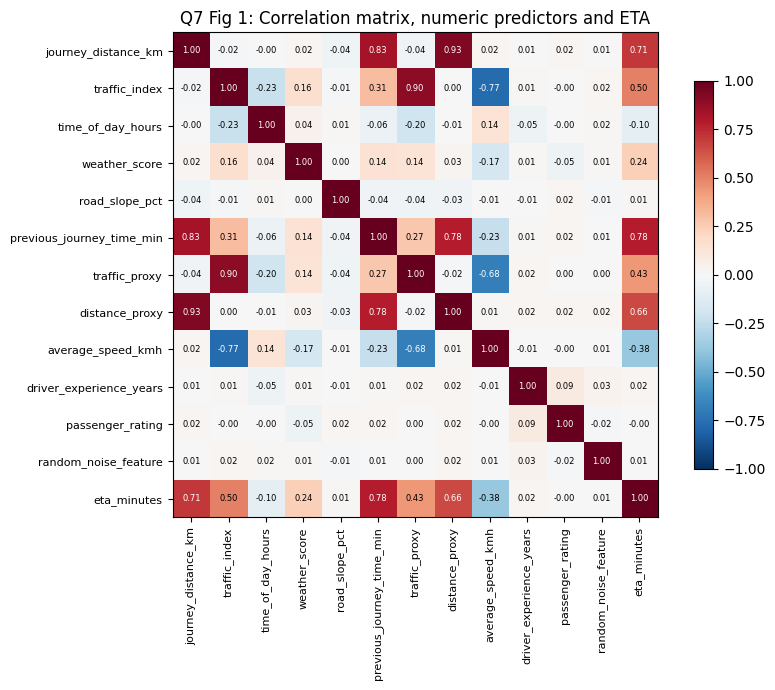

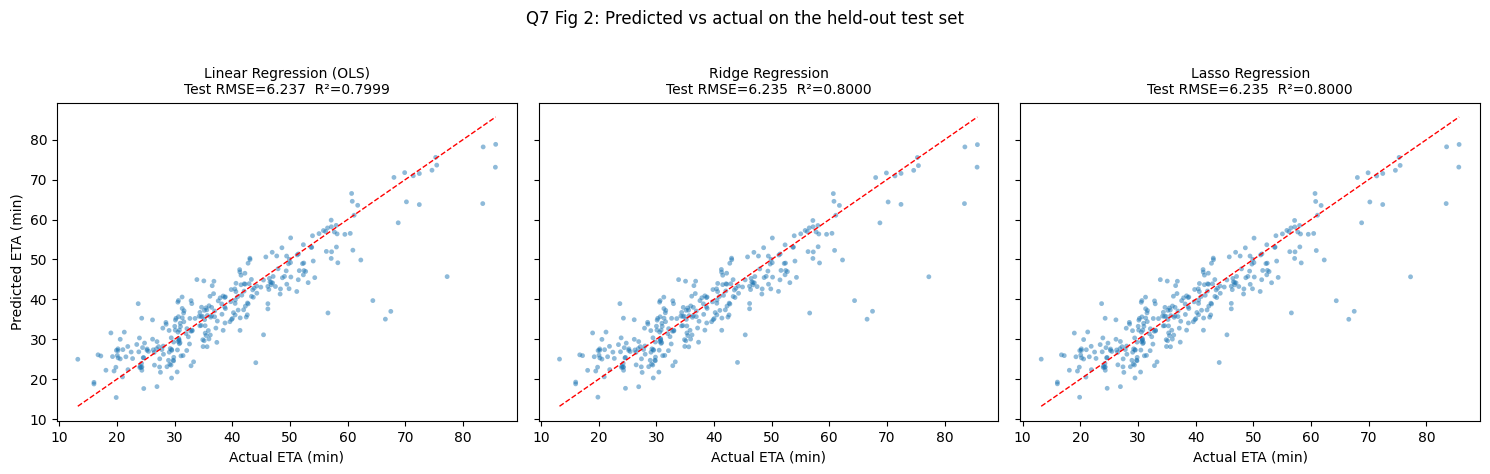

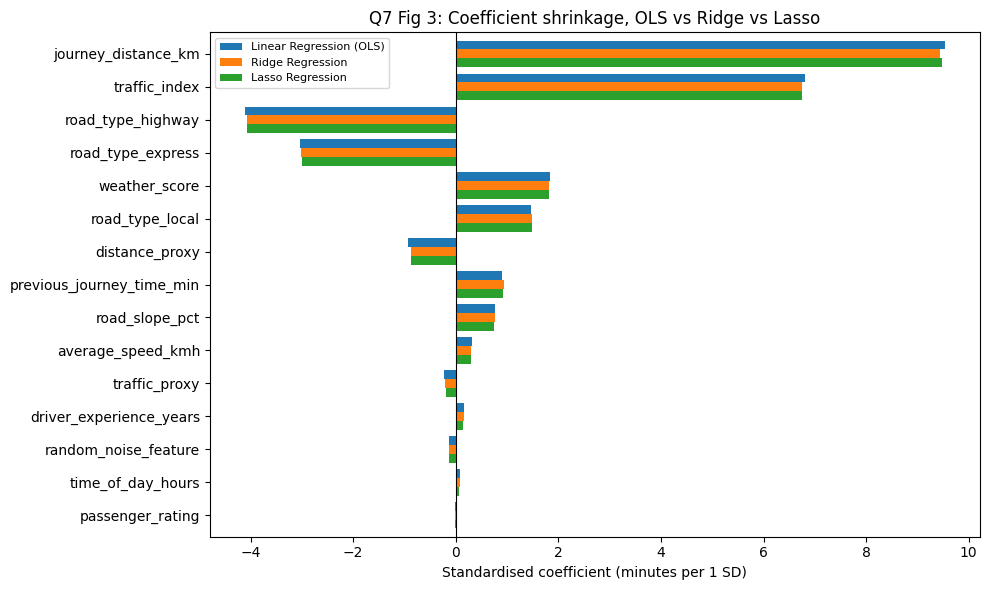

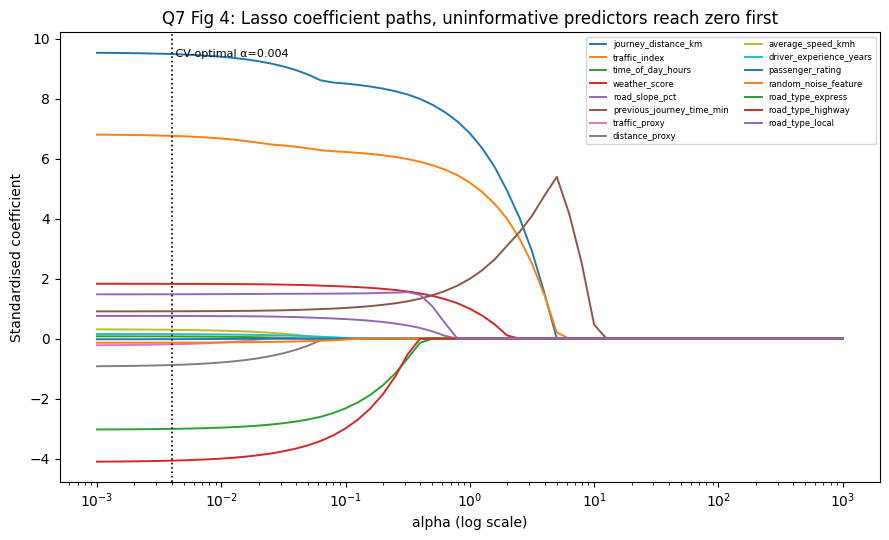


Figures written: figures/q7_fig1..4
Tables written:  output/q7_metrics.csv, q7_coefficients.csv, q7_vif.csv


In [8]:
"""
Q7 - YEGO ETA prediction: OLS vs Ridge vs Lasso
MIT91207 Machine Learning, Assignment 1
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from statsmodels.stats.outliers_influence import variance_inflation_factor

RS = 42
np.random.seed(RS)
df = pd.read_csv("data/synthetic_ETA.csv")

# ---------- 1. Prepare ----------
TARGET = "eta_minutes"
df = df.drop(columns=["observation_id"])          # identifier, never a predictor
y = df[TARGET]
X = df.drop(columns=[TARGET])
num_cols = [c for c in X.columns if X[c].dtype != object]
cat_cols = [c for c in X.columns if X[c].dtype == object]

print("="*78); print("1. DATA PREPARATION")
print(f"observations: {len(df)}   predictors: {X.shape[1]} ({len(num_cols)} numeric, {len(cat_cols)} categorical)")
print(f"missing values: {df.isna().sum().sum()}   duplicate rows: {df.duplicated().sum()}")
print(f"target {TARGET}: mean={y.mean():.2f} sd={y.std():.2f} min={y.min():.2f} max={y.max():.2f}")

# ---------- 2. Multicollinearity diagnosis ----------
print("\n"+"="*78); print("2. MULTICOLLINEARITY (variance inflation factors, numeric predictors)")
Xn = X[num_cols].copy()
Xs = pd.DataFrame(StandardScaler().fit_transform(Xn), columns=num_cols)
Xs.insert(0, "const", 1.0)
vif = pd.DataFrame({
    "predictor": num_cols,
    "VIF": [variance_inflation_factor(Xs.values, i) for i in range(1, Xs.shape[1])],
}).sort_values("VIF", ascending=False)
print(vif.to_string(index=False, float_format=lambda v: f"{v:8.2f}"))

corr = X[num_cols].corrwith(y).sort_values(key=abs, ascending=False)
print("\nCorrelation of each numeric predictor with eta_minutes:")
print(corr.to_string(float_format=lambda v: f"{v:7.3f}"))

pairs = X[num_cols].corr().abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 0.999].drop_duplicates()
print("\nStrongest predictor-predictor correlations:")
for (a, b), v in pairs.head(5).items():
    print(f"  {a:26s} <-> {b:26s} r = {v:.3f}")

# ---------- 3. Split: train / test, CV inside train ----------
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=RS)
print("\n"+"="*78); print("3. SPLIT")
print(f"train: {len(X_tr)}   test (held out, touched once): {len(X_te)}")

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
])
cv = KFold(n_splits=10, shuffle=True, random_state=RS)

# ---------- 4. Fit three models ----------
print("\n"+"="*78); print("4. MODEL FITTING (alpha chosen by 10-fold CV on training set only)")
alphas = np.logspace(-3, 3, 61)
models, results = {}, []

specs = [
    ("Linear Regression (OLS)", LinearRegression(), None),
    ("Ridge Regression",        Ridge(random_state=RS),        {"model__alpha": alphas}),
    ("Lasso Regression",        Lasso(random_state=RS, max_iter=50000), {"model__alpha": alphas}),
]

for name, est, grid in specs:
    pipe = Pipeline([("pre", pre), ("model", est)])
    if grid:
        gs = GridSearchCV(pipe, grid, scoring="neg_root_mean_squared_error", cv=cv, n_jobs=-1)
        gs.fit(X_tr, y_tr)
        best, alpha = gs.best_estimator_, gs.best_params_["model__alpha"]
    else:
        best, alpha = pipe.fit(X_tr, y_tr), np.nan
    cv_rmse = -cross_val_score(best, X_tr, y_tr, scoring="neg_root_mean_squared_error", cv=cv).mean()
    p_tr, p_te = best.predict(X_tr), best.predict(X_te)
    results.append({
        "Model": name, "alpha": alpha, "CV RMSE": cv_rmse,
        "Train RMSE": mean_squared_error(y_tr, p_tr)**0.5,
        "Test RMSE":  mean_squared_error(y_te, p_te)**0.5,
        "Test MAE":   mean_absolute_error(y_te, p_te),
        "Train R2":   r2_score(y_tr, p_tr), "Test R2": r2_score(y_te, p_te),
    })
    models[name] = best
    print(f"  {name:26s} alpha={alpha if alpha==alpha else 0:8.4f}  CV RMSE={cv_rmse:.4f}")

res = pd.DataFrame(results)
print("\n"+"="*78); print("5. PERFORMANCE COMPARISON")
print(res.to_string(index=False, float_format=lambda v: f"{v:9.4f}"))

# ---------- 6. Coefficients ----------
feat = models["Linear Regression (OLS)"].named_steps["pre"].get_feature_names_out()
feat = [f.split("__", 1)[1] for f in feat]
coef = pd.DataFrame({n: m.named_steps["model"].coef_ for n, m in models.items()}, index=feat)
coef["|OLS|"] = coef["Linear Regression (OLS)"].abs()
coef = coef.sort_values("|OLS|", ascending=False).drop(columns="|OLS|")
print("\n"+"="*78); print("6. STANDARDISED COEFFICIENTS (minutes of ETA per 1 SD of predictor)")
print(coef.to_string(float_format=lambda v: f"{v:9.3f}"))

nz = (coef["Lasso Regression"].abs() < 1e-8)
print(f"\nPredictors eliminated by Lasso ({nz.sum()} of {len(coef)}):")
for f in coef.index[nz]: print("  -", f)

res.to_csv("output/q7_metrics.csv", index=False)
coef.to_csv("output/q7_coefficients.csv")
vif.to_csv("output/q7_vif.csv", index=False)

# ---------- 7. Figures ----------
fig, ax = plt.subplots(figsize=(9, 7))
cm = X[num_cols + []].assign(eta_minutes=y).corr()
im = ax.imshow(cm, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(cm))); ax.set_xticklabels(cm.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(cm))); ax.set_yticklabels(cm.columns, fontsize=8)
for i in range(len(cm)):
    for j in range(len(cm)):
        ax.text(j, i, f"{cm.iloc[i,j]:.2f}", ha="center", va="center", fontsize=6,
                color="white" if abs(cm.iloc[i, j]) > 0.6 else "black")
ax.set_title("Q7 Fig 1: Correlation matrix, numeric predictors and ETA")
fig.colorbar(im, shrink=0.8); fig.tight_layout(); fig.savefig("figures/q7_fig1_corr.png", dpi=150); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.6), sharex=True, sharey=True)
for axx, (n, m) in zip(axes, models.items()):
    p = m.predict(X_te)
    axx.scatter(y_te, p, s=12, alpha=0.5, edgecolor="none")
    lo, hi = y_te.min(), y_te.max()
    axx.plot([lo, hi], [lo, hi], "r--", lw=1)
    axx.set_title(f"{n}\nTest RMSE={mean_squared_error(y_te,p)**0.5:.3f}  R²={r2_score(y_te,p):.4f}", fontsize=10)
    axx.set_xlabel("Actual ETA (min)")
axes[0].set_ylabel("Predicted ETA (min)")
fig.suptitle("Q7 Fig 2: Predicted vs actual on the held-out test set", y=1.02)
fig.tight_layout(); fig.savefig("figures/q7_fig2_pred.png", dpi=150, bbox_inches="tight"); plt.show()

fig, ax = plt.subplots(figsize=(10, 6))
coef.plot.barh(ax=ax, width=0.8)
ax.axvline(0, color="k", lw=0.8); ax.invert_yaxis()
ax.set_xlabel("Standardised coefficient (minutes per 1 SD)")
ax.set_title("Q7 Fig 3: Coefficient shrinkage, OLS vs Ridge vs Lasso")
ax.legend(fontsize=8); fig.tight_layout(); fig.savefig("figures/q7_fig3_coef.png", dpi=150); plt.show()

# Lasso path
fig, ax = plt.subplots(figsize=(9, 5.5))
paths = []
for a in alphas:
    p = Pipeline([("pre", pre), ("model", Lasso(alpha=a, random_state=RS, max_iter=50000))]).fit(X_tr, y_tr)
    paths.append(p.named_steps["model"].coef_)
paths = np.array(paths)
for i, f in enumerate(feat):
    ax.plot(alphas, paths[:, i], label=f, lw=1.4)
best_a = res.loc[res.Model == "Lasso Regression", "alpha"].iloc[0]
ax.axvline(best_a, color="k", ls=":", lw=1.2)
ax.text(best_a, ax.get_ylim()[1]*0.92, f" CV-optimal α={best_a:.3f}", fontsize=8)
ax.set_xscale("log"); ax.set_xlabel("alpha (log scale)"); ax.set_ylabel("Standardised coefficient")
ax.set_title("Q7 Fig 4: Lasso coefficient paths, uninformative predictors reach zero first")
ax.legend(fontsize=6, ncol=2); fig.tight_layout(); fig.savefig("figures/q7_fig4_path.png", dpi=150); plt.show()

print("\nFigures written: figures/q7_fig1..4")
print("Tables written:  output/q7_metrics.csv, q7_coefficients.csv, q7_vif.csv")

### Question 7 code: `code/q7b_complexity.py`

A. ONE-STANDARD-ERROR RULE (Lasso)


best alpha            = 0.0039   CV RMSE = 5.7117 (SE 0.1536)
1-SE threshold        = 5.8653
largest alpha within  = 0.2868   CV RMSE = 5.8563

Retained by the 1-SE model (8 of 15):
    journey_distance_km             8.184
    traffic_index                   6.015
    weather_score                   1.594
    road_type_local                 1.543
    previous_journey_time_min       1.213
    road_type_express              -0.885
    road_type_highway              -0.857
    road_slope_pct                  0.468
Dropped (7): time_of_day_hours, traffic_proxy, distance_proxy, average_speed_kmh, driver_experience_years, passenger_rating, random_noise_feature

                  Model    alpha  predictors kept  Test RMSE  Test R2
OLS (all 15 predictors)      NaN               15     6.2366   0.7999
     Lasso (CV-optimal)   0.0039               15     6.2355   0.8000
      Lasso (1-SE rule)   0.2868                8     6.3680   0.7914

B. COEFFICIENT STABILITY UNDER MULTICOLLINEARITY (300 

                predictor    OLS sd  Ridge sd  reduction %  OLS sign flips %
      journey_distance_km     1.645     0.864       47.467             0.000
        road_type_highway     1.507     0.909       39.686             0.000
            traffic_index     1.209     0.758       37.320             0.000
           distance_proxy     1.180     0.768       34.956            26.333
        road_type_express     1.075     0.747       30.462             0.333
          road_type_local     1.040     0.742       28.648             6.667
            traffic_proxy     0.989     0.701       29.104            41.333
previous_journey_time_min     0.950     0.702       26.113            17.667
        average_speed_kmh     0.620     0.540       12.882            27.667
            weather_score     0.460     0.445        3.370             0.000
         passenger_rating     0.448     0.416        7.149            44.000
     random_noise_feature     0.427     0.403        5.785            39.000

 n_train       OLS     Ridge     Lasso  OLS - Ridge
      30     8.520     7.688     7.544        0.832
      50     7.344     7.182     6.972        0.162
      80     6.833     6.847     6.693       -0.014
     120     6.610     6.656     6.595       -0.046
     200     6.421     6.462     6.475       -0.042
     400     6.331     6.348     6.449       -0.016
     800     6.253     6.252     6.393        0.001
    1200     6.237     6.234     6.381        0.003


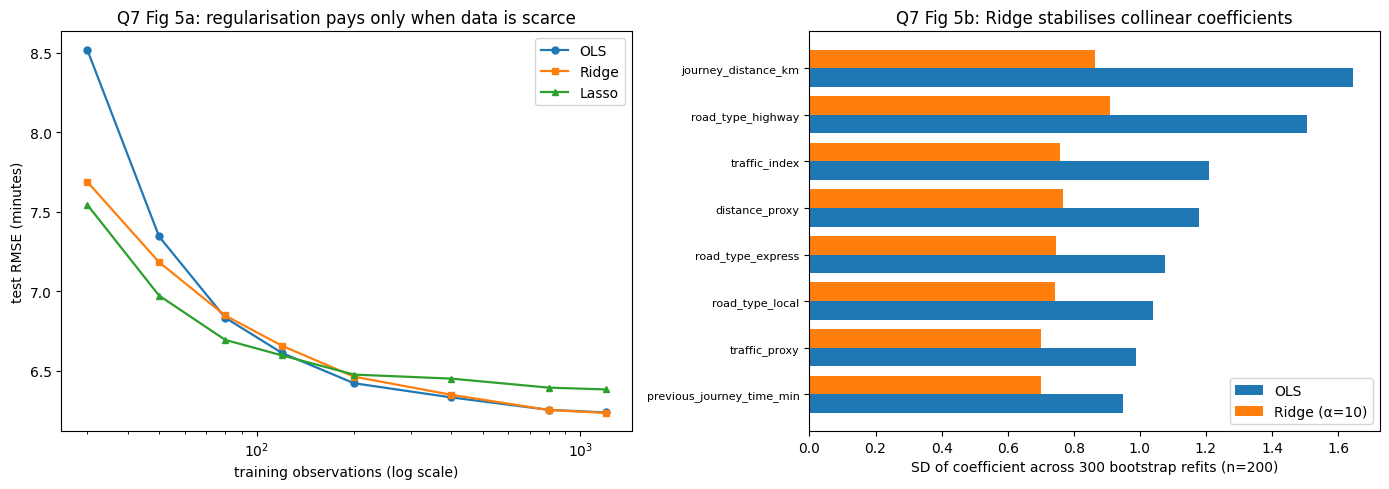


Figure written: figures/q7_fig5_complexity.png


In [9]:
"""
Q7 (c)/(d) - why the three models tie on RMSE, and where regularisation still pays:
  A. 1-SE rule: cheapest model statistically indistinguishable from the best
  B. Coefficient stability under multicollinearity (bootstrap)
  C. Small-sample behaviour (learning curve) - when regularisation actually matters
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

RS = 42; rng = np.random.default_rng(RS)
df = pd.read_csv("data/synthetic_ETA.csv").drop(columns=["observation_id"])
y = df["eta_minutes"]; X = df.drop(columns=["eta_minutes"])
num = [c for c in X if X[c].dtype != object]; cat = [c for c in X if X[c].dtype == object]
pre = lambda: ColumnTransformer([("num", StandardScaler(), num),
                                 ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat)])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.20, random_state=RS)
cv = KFold(10, shuffle=True, random_state=RS)
alphas = np.logspace(-3, 2, 60)

# ---------------- A. one-standard-error rule ----------------
print("="*78); print("A. ONE-STANDARD-ERROR RULE (Lasso)")
gs = GridSearchCV(Pipeline([("pre", pre()), ("model", Lasso(random_state=RS, max_iter=50000))]),
                  {"model__alpha": alphas}, scoring="neg_root_mean_squared_error",
                  cv=cv, n_jobs=-1, return_train_score=False).fit(X_tr, y_tr)
cvr = pd.DataFrame(gs.cv_results_)
mean_rmse = -cvr["mean_test_score"].values
se_rmse = cvr["std_test_score"].values / np.sqrt(cv.get_n_splits())
best_i = mean_rmse.argmin()
thresh = mean_rmse[best_i] + se_rmse[best_i]
elig = np.where(mean_rmse <= thresh)[0]
a_1se = alphas[elig.max()]
print(f"best alpha            = {alphas[best_i]:.4f}   CV RMSE = {mean_rmse[best_i]:.4f} (SE {se_rmse[best_i]:.4f})")
print(f"1-SE threshold        = {thresh:.4f}")
print(f"largest alpha within  = {a_1se:.4f}   CV RMSE = {mean_rmse[elig.max()]:.4f}")

feat_names = None; rows = []
for label, alpha in [("Lasso (CV-optimal)", alphas[best_i]), ("Lasso (1-SE rule)", a_1se)]:
    m = Pipeline([("pre", pre()), ("model", Lasso(alpha=alpha, random_state=RS, max_iter=50000))]).fit(X_tr, y_tr)
    feat_names = [f.split("__", 1)[1] for f in m.named_steps["pre"].get_feature_names_out()]
    c = m.named_steps["model"].coef_
    p = m.predict(X_te)
    rows.append({"Model": label, "alpha": alpha, "predictors kept": int((np.abs(c) > 1e-8).sum()),
                 "Test RMSE": mean_squared_error(y_te, p)**0.5, "Test R2": r2_score(y_te, p)})
    if "1-SE" in label:
        kept = pd.Series(c, index=feat_names)
        print(f"\nRetained by the 1-SE model ({(np.abs(c)>1e-8).sum()} of {len(c)}):")
        for f, v in kept[kept.abs() > 1e-8].sort_values(key=abs, ascending=False).items():
            print(f"    {f:28s} {v:8.3f}")
        print(f"Dropped ({(np.abs(c)<=1e-8).sum()}): " + ", ".join(kept[kept.abs() <= 1e-8].index))
full = Pipeline([("pre", pre()), ("model", LinearRegression())]).fit(X_tr, y_tr)
pf = full.predict(X_te)
rows.insert(0, {"Model": "OLS (all 15 predictors)", "alpha": np.nan, "predictors kept": 15,
                "Test RMSE": mean_squared_error(y_te, pf)**0.5, "Test R2": r2_score(y_te, pf)})
tblA = pd.DataFrame(rows)
print("\n"+tblA.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))
tblA.to_csv("output/q7b_1se.csv", index=False)

# ---------------- B. coefficient stability ----------------
print("\n"+"="*78); print("B. COEFFICIENT STABILITY UNDER MULTICOLLINEARITY (300 bootstrap refits, n=200)")
B, nb = 300, 200
store = {"OLS": [], "Ridge": []}
for _ in range(B):
    idx = rng.choice(len(X_tr), nb, replace=True)
    xb, yb = X_tr.iloc[idx], y_tr.iloc[idx]
    for nm, est in [("OLS", LinearRegression()), ("Ridge", Ridge(alpha=10.0, random_state=RS))]:
        m = Pipeline([("pre", pre()), ("model", est)]).fit(xb, yb)
        store[nm].append(m.named_steps["model"].coef_)
stab = pd.DataFrame({
    "predictor": feat_names,
    "OLS sd":   np.std(np.array(store["OLS"]), axis=0),
    "Ridge sd": np.std(np.array(store["Ridge"]), axis=0),
})
stab["reduction %"] = (1 - stab["Ridge sd"] / stab["OLS sd"]) * 100
stab["OLS sign flips %"] = [ (np.sign(np.array(store["OLS"])[:, i]) != np.sign(np.median(np.array(store["OLS"])[:, i]))).mean()*100
                             for i in range(len(feat_names)) ]
stab = stab.sort_values("OLS sd", ascending=False)
print(stab.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
stab.to_csv("output/q7b_stability.csv", index=False)

# ---------------- C. learning curve ----------------
print("\n"+"="*78); print("C. TEST RMSE BY TRAINING-SET SIZE (mean of 40 random draws)")
sizes = [30, 50, 80, 120, 200, 400, 800, 1200]
out = []
for n in sizes:
    acc = {"OLS": [], "Ridge": [], "Lasso": []}
    for r in range(40):
        idx = np.random.default_rng(RS + r).choice(len(X_tr), n, replace=False)
        xb, yb = X_tr.iloc[idx], y_tr.iloc[idx]
        for nm, est in [("OLS", LinearRegression()),
                        ("Ridge", Ridge(alpha=10.0, random_state=RS)),
                        ("Lasso", Lasso(alpha=0.3, random_state=RS, max_iter=50000))]:
            m = Pipeline([("pre", pre()), ("model", est)]).fit(xb, yb)
            acc[nm].append(mean_squared_error(y_te, m.predict(X_te))**0.5)
    out.append({"n_train": n, **{k: np.mean(v) for k, v in acc.items()}})
lc = pd.DataFrame(out)
lc["OLS - Ridge"] = lc["OLS"] - lc["Ridge"]
print(lc.to_string(index=False, float_format=lambda v: f"{v:9.3f}"))
lc.to_csv("output/q7b_learning_curve.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ax = axes[0]
for k, st in [("OLS", "o-"), ("Ridge", "s-"), ("Lasso", "^-")]:
    ax.plot(lc.n_train, lc[k], st, lw=1.6, ms=5, label=k)
ax.set_xscale("log"); ax.set_xlabel("training observations (log scale)")
ax.set_ylabel("test RMSE (minutes)"); ax.legend()
ax.set_title("Q7 Fig 5a: regularisation pays only when data is scarce")
ax = axes[1]
top = stab.head(8).iloc[::-1]
yp = np.arange(len(top))
ax.barh(yp - 0.2, top["OLS sd"], 0.4, label="OLS")
ax.barh(yp + 0.2, top["Ridge sd"], 0.4, label="Ridge (α=10)")
ax.set_yticks(yp); ax.set_yticklabels(top["predictor"], fontsize=8)
ax.set_xlabel("SD of coefficient across 300 bootstrap refits (n=200)"); ax.legend()
ax.set_title("Q7 Fig 5b: Ridge stabilises collinear coefficients")
fig.tight_layout(); fig.savefig("figures/q7_fig5_complexity.png", dpi=150); plt.show()
print("\nFigure written: figures/q7_fig5_complexity.png")

# Question 8: Product-launch survey analysis (12 marks)

600 unique responses after cleaning, with stated willingness to purchase at 36.3%.
Script: `code/q8_survey_eda.py`.

## 8(a) Exploratory strategy (3 marks)

The brief is explicit that management wants evidence for a decision rather than a summary
of responses. That shapes the analysis: every step should reduce uncertainty about whether
to launch, at what price, and to whom.

Establish what the sample can and cannot support, first. With 600 responses, the 95%
margin of error on a single proportion is ±3.8 percentage points. Any difference smaller
than that is not a finding. Stating this before analysis prevents the familiar pattern of
reporting a 2-point gap between subgroups as though it were real.

Data quality, before any interpretation. Twelve duplicate submissions were present and
removed. `satisfaction_current` is missing for 4.3% of respondents and
`expected_price_band` for 3.0%. Non-response is checked for informativeness and not assumed neutral: willingness among those who skipped the satisfaction question is 0.308
against 0.366 for those who answered, a gap in the direction one would expect from
disengagement, though the subgroup of 26 is too small to conclude from.

Distributions before relationships. Each variable's measurement level determines what
may be done with it. `expected_price_band` is ordinal and its ordering must be preserved,
as in Question 4. `occupation` and `preferred_feature` are nominal. `satisfaction_current`
is a five-point scale, so medians and rank tests are safer than means, although both are
reported.

Relationships selected by decision relevance. Only three or four comparisons actually
bear on the launch: does prior experience with similar products predict willingness, does
willingness vary with expected price, does dissatisfaction with the current solution
predict willingness, and do feature preferences differ by segment. Each is paired with an
appropriate statistical test, so that a visible pattern is separated from a real one.

Segments last, because segmentation is only meaningful once the drivers are known.

## 8(b) Visualisations (4 marks)

Each chart is chosen from the measurement levels of the two variables involved, and each
carries the test statistic that justifies reading it.

![Survey relationships](figures/q8_fig1_survey.png)

(a) Prior use against willingness. Nominal by binary, so a grouped bar of proportions.
A pie chart would be wrong, since the comparison is between two rates rather than parts of
a whole.

```
willingness: prior users 45.5% vs non-users 28.6%
chi-square p = 2.82e-05, Cramer V = 0.171
```

(b) Expected price band against willingness. Ordinal by binary, so an ordered bar with a
trend test. The category order carries meaning and must not be sorted by frequency.

```
                       n  willing %
<5k                  177       27.7
5-15k                187       37.4
15-30k               112       38.4
30-50k                70       42.9
>50k                  36       58.3
Spearman rho = +0.144 (p = 5.10e-04)
```

(c) Current satisfaction against willingness. Ordinal by binary, so a box plot. It
shows the median, the spread and the overlap, where a bar of means would hide all three.

```
median satisfaction, willing = 2.0 vs not willing = 4.0  (Mann-Whitney p = 5.45e-08)
mean satisfaction,   willing = 2.68 vs not willing = 3.35
```

(d) Preferred feature by age group. Nominal by nominal, so a heatmap of column
percentages. Column rather than row percentages, because the question is what each age
group wants, not how each feature's supporters are distributed.

```
age_group          18-24  25-34  35-44  45-54   55+
local language      32.1   24.4   17.4   29.8  22.2
mobile money        30.0   37.3   27.5   22.6  28.9
offline mode        17.9    9.8   28.3   27.4  20.0
chi-square p = 5.13e-04, Cramer V = 0.131
```

## 8(c) Insights bearing on the launch (3 marks)

Insight 1: the addressable market is the dissatisfied, not the unfamiliar. Willingness
among prior users of similar products is 45.5% against 28.6% among non-users, a 16.9-point
gap at p < 0.001. Dissatisfaction points the same way, with median satisfaction of 2 among
willing buyers against 4 among unwilling ones (p < 0.001). The two together describe a
specific buyer: someone who has used a competing product and found it wanting. The
implication for the launch is that positioning should be comparative and migration-focused,
addressing people who already understand the category, instead of educational messaging
aimed at first-time users. It also identifies the competitor's dissatisfied base as the
primary acquisition channel.

Insight 2: price is not the binding constraint, and the pricing assumption is probably
wrong. Willingness *rises* with the price band the respondent already expects to pay,
from 27.7% in the under-5,000 band to 58.3% above 50,000, with Spearman ρ = +0.144 at
p < 0.001. The usual reading of a price question, that a lower price widens the market, is
contradicted here. Respondents anchored to low prices are the least likely to buy at any
price, which is consistent with them placing little value on the category. The implication
is that a low-price launch would attract the least willing segment while surrendering
margin on the most willing one. The caution attached to this is that the highest band
contains only 36 respondents, so the 58.3% figure carries a wide interval and the direction
of the trend is better supported than its magnitude.

Supporting finding on the feature roadmap. Preferences differ significantly by age
(p < 0.001), but Cramér's V of 0.131 indicates a weak association. Mobile money is the top
or joint-top preference in every age group, ranging from 22.6% to 37.3%. The practical
conclusion is that mobile money is a universal requirement, not a segment feature,
while offline mode shows a genuine split, at 9.8% among 25 to 34 year olds and 28.3% among
35 to 44 year olds, and is a candidate for later differentiation rather than for the first
release.

Segment concentration.

| Segment | n | Willing | Share of sample | Share of all willing |
|---|---|---|---|---|
| Experienced, higher budget | 100 | 54.0% | 16.7% | 24.8% |
| Experienced, lower budget | 175 | 40.6% | 29.2% | 32.6% |
| New, higher budget | 126 | 32.5% | 21.0% | 18.8% |
| New, lower budget | 199 | 26.1% | 33.2% | 23.9% |

Experienced buyers with a higher budget are 16.7% of respondents and 24.8% of everyone
willing to buy. The two experienced segments together are 45.8% of the sample and 57.4% of
willing buyers. A launch targeting them addresses well over half the demand with under half
the outreach.

## 8(d) Limitation and further evidence (2 marks)

The limitation: stated willingness to purchase is not purchase. Every finding here
rests on what 600 people said they would do about a product that does not exist and that
they have not seen priced. Three distinct biases operate, and they do not cancel. Hypothetical
bias, where survey willingness routinely overstates purchase by a large factor, so the
36.3% headline is an upper bound and not a forecast. Acquiescence and social-desirability
effects, where respondents give the answer the questioner appears to want. And selection,
since the analysis can say nothing about who declined to take the survey, and non-respondents
are plausibly the least interested. There is a further structural point: because the sample
is dominated by people already familiar with the category, and familiarity is the strongest
predictor of willingness, the survey may be measuring the enthusiasm of an existing market instead of the size of a new one.

Additional evidence to obtain before committing the budget. In rough order of cost:

A discrete-choice or conjoint exercise, in which respondents choose between specified
bundles at specified prices instead of reporting an abstract willingness. This produces
price-elasticity estimates that the current ordinal price question cannot, and the ordering
effect found in 8(c) needs exactly that test before it is trusted as a pricing rule.

A pre-launch commitment test: a landing page with real pricing, measuring sign-ups or
pre-orders. A small financial or registration commitment separates intent from politeness
far more reliably than any survey instrument, and it can be run in days.

A limited pilot in one segment, preferably the experienced higher-budget group, measuring
actual conversion, activation and retention. Retention is the number that determines whether
the product is viable, and no survey can supply it.

Market sizing from independent data, since 600 respondents can establish the *proportion*
willing but not the absolute size of the addressable market.

Competitive and channel analysis, because the finding that the buyer is a dissatisfied
competitor customer makes the competitor's switching costs and response the decisive
commercial variable, and the survey says nothing about either.

Recommendation to management: treat the survey as having identified who to sell to and
what to build first, and as having established nothing reliable about how many will buy or
at what price. Fund the commitment test and the pilot before the full launch.

### Question 8 code: `code/q8_survey_eda.py`

1. Q8(a) DATA QUALITY BEFORE ANY INTERPRETATION
  responses=612  duplicate rows=12
  after removing duplicate submissions: 600
                      missing    %
expected_price_band        18  3.0
satisfaction_current       26  4.3
  willingness among non-responders to satisfaction: 0.308 vs 0.366 (n=26)
  overall stated willingness to purchase: 36.3%
  margin of error on that proportion at 95%: +/-3.8 pp

2. Q8(b)(c) RELATIONSHIPS, WITH A TEST BEHIND EACH CHART

  (i) prior use of a similar product x willingness  [nominal x binary -> grouped bar]
willing_to_purchase    0    1
used_similar_before          
no                   232   93
yes                  150  125
      willingness: prior users 45.5% vs non-users 28.6%  (chi2 p=2.82e-05, Cramer V=0.171)

  (ii) expected price band x willingness  [ordinal x binary -> ordered bar + trend test]
                       n  willing %
expected_price_band                
<5k                  177       27.7
5-15k                187       37.4
1

/var/folders/0x/kn1k9mhx0n11l5yfpn9l6sl80000gn/T/ipykernel_32312/3930533344.py:110: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([b.values,a.values],labels=["not willing","willing"])


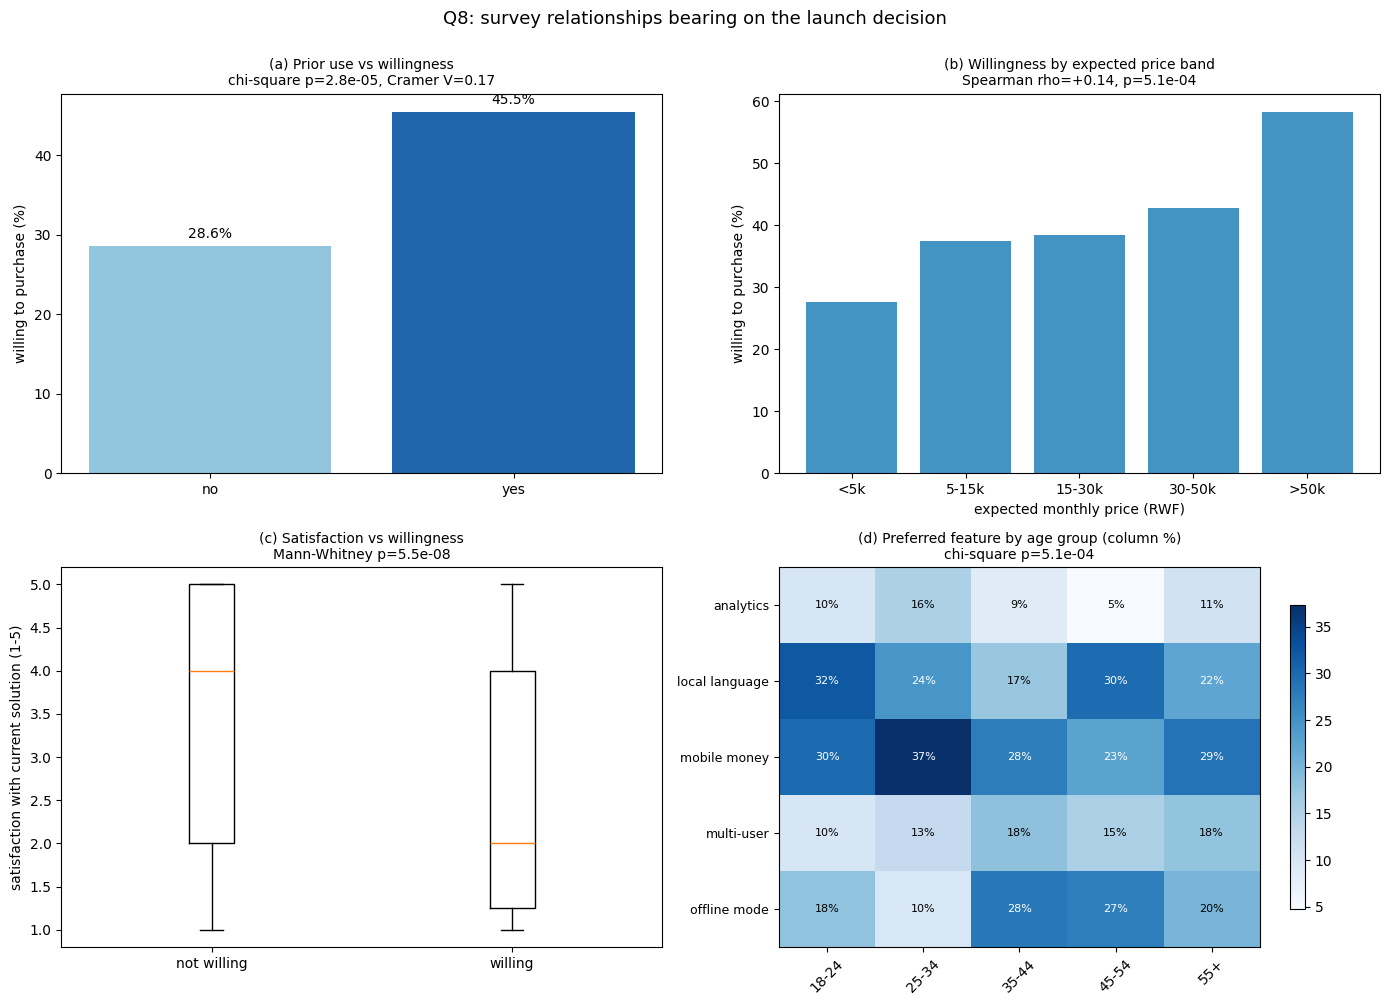


figure: figures/q8_fig1_survey.png


In [10]:
"""
Q8 - product-launch survey: exploratory analysis aimed at a launch decision.
Charts are chosen from the measurement level of each variable, not by habit.
"""
import numpy as np, pandas as pd, matplotlib
import matplotlib.pyplot as plt
from scipy import stats
RS=42; rng=np.random.default_rng(RS); N=600

age_b=["18-24","25-34","35-44","45-54","55+"]
occ=["student","salaried","self_employed","public_sector","unemployed"]
price_b=["<5k","5-15k","15-30k","30-50k",">50k"]           # RWF per month, ordinal
feats=["offline mode","mobile money","multi-user","analytics","local language"]
d=pd.DataFrame({
 "respondent_id":np.arange(1,N+1),
 "age_group":rng.choice(age_b,N,p=[.22,.34,.22,.14,.08]),
 "occupation":rng.choice(occ,N,p=[.18,.34,.26,.14,.08]),
 "used_similar_before":rng.choice(["yes","no"],N,p=[.46,.54]),
 "expected_price_band":rng.choice(price_b,N,p=[.28,.31,.22,.13,.06]),
 "satisfaction_current":rng.integers(1,6,N)})
pri={"<5k":0,"5-15k":1,"15-30k":2,"30-50k":3,">50k":4}
d["price_rank"]=d.expected_price_band.map(pri)
lo=(-0.55+0.85*(d.used_similar_before=="yes")+0.40*d.price_rank
    -0.42*d.satisfaction_current+0.55*d.age_group.isin(["25-34","35-44"])
    +rng.normal(0,.7,N))
d["willing_to_purchase"]=(1/(1+np.exp(-lo))>rng.random(N)).astype(int)
d["preferred_feature"]=[rng.choice(feats,p=([.12,.34,.10,.14,.30] if a in("18-24","25-34")
                                            else [.24,.26,.16,.12,.22]))
                        for a in d.age_group]
d.loc[rng.random(N)<.05,"satisfaction_current"]=np.nan
d.loc[rng.random(N)<.03,"expected_price_band"]=np.nan
d=pd.concat([d,d.sample(12,random_state=RS)],ignore_index=True)     # duplicated submissions

print("="*80); print("1. Q8(a) DATA QUALITY BEFORE ANY INTERPRETATION")
print(f"  responses={len(d)}  duplicate rows={d.duplicated(subset='respondent_id').sum()}")
d=d.drop_duplicates(subset="respondent_id").reset_index(drop=True)
miss=pd.DataFrame({"missing":d.isna().sum(),"%":(d.isna().mean()*100).round(1)})
print(f"  after removing duplicate submissions: {len(d)}")
print(miss[miss.missing>0].to_string())
m=d.satisfaction_current.isna()
print(f"  willingness among non-responders to satisfaction: {d.willing_to_purchase[m].mean():.3f} "
      f"vs {d.willing_to_purchase[~m].mean():.3f} (n={m.sum()})")
print(f"  overall stated willingness to purchase: {d.willing_to_purchase.mean():.1%}")
print(f"  margin of error on that proportion at 95%: "
      f"+/-{1.96*np.sqrt(d.willing_to_purchase.mean()*(1-d.willing_to_purchase.mean())/len(d))*100:.1f} pp")

def cramers_v(t):
    chi2=stats.chi2_contingency(t)[0]; n=t.values.sum()
    return np.sqrt(chi2/(n*(min(t.shape)-1)))

print("\n"+"="*80); print("2. Q8(b)(c) RELATIONSHIPS, WITH A TEST BEHIND EACH CHART")
print("\n  (i) prior use of a similar product x willingness  [nominal x binary -> grouped bar]")
t1=pd.crosstab(d.used_similar_before,d.willing_to_purchase)
chi2,p1,_,_=stats.chi2_contingency(t1)
print(t1.to_string())
r1=d.groupby("used_similar_before").willing_to_purchase.mean()
print(f"      willingness: prior users {r1['yes']:.1%} vs non-users {r1['no']:.1%}  "
      f"(chi2 p={p1:.2e}, Cramer V={cramers_v(t1):.3f})")

print("\n  (ii) expected price band x willingness  [ordinal x binary -> ordered bar + trend test]")
dd=d.dropna(subset=["expected_price_band"])
t2=pd.crosstab(dd.expected_price_band,dd.willing_to_purchase).reindex(price_b)
rate=(t2[1]/t2.sum(axis=1))
print(pd.DataFrame({"n":t2.sum(axis=1),"willing %":(rate*100).round(1)}).to_string())
rho,p2=stats.spearmanr(dd.price_rank,dd.willing_to_purchase)
print(f"      Spearman rho={rho:+.3f} (p={p2:.2e}): willingness RISES with the price the")
print(f"      respondent already expects to pay, so the constraint is not price sensitivity")

print("\n  (iii) current satisfaction x willingness  [ordinal x binary -> box plot]")
s=d.dropna(subset=["satisfaction_current"])
a=s.satisfaction_current[s.willing_to_purchase==1]; b=s.satisfaction_current[s.willing_to_purchase==0]
u,p3=stats.mannwhitneyu(a,b)
print(f"      median satisfaction, willing={a.median():.1f} vs not willing={b.median():.1f}  "
      f"(Mann-Whitney p={p3:.2e})")
print(f"      mean satisfaction, willing={a.mean():.2f} vs not willing={b.mean():.2f}")

print("\n  (iv) preferred feature x age group  [nominal x nominal -> heatmap of column shares]")
t4=pd.crosstab(d.preferred_feature,d.age_group)[age_b]
share=(t4/t4.sum())*100
print(share.round(1).to_string())
chi2,p4,_,_=stats.chi2_contingency(t4)
print(f"      chi2 p={p4:.2e}, Cramer V={cramers_v(t4):.3f}")

print("\n"+"="*80); print("3. Q8(c) SEGMENTS THAT CARRY THE DECISION")
d["segment"]=np.where(d.used_similar_before.eq("yes")&d.price_rank.ge(2),"experienced, higher budget",
             np.where(d.used_similar_before.eq("yes"),"experienced, lower budget",
             np.where(d.price_rank.ge(2),"new, higher budget","new, lower budget")))
seg=d.groupby("segment").agg(n=("respondent_id","size"),
        willing=("willing_to_purchase","mean"),
        satisfaction=("satisfaction_current","mean")).sort_values("willing",ascending=False)
seg["share of sample"]=seg.n/len(d)
seg["share of all willing"]=d[d.willing_to_purchase==1].segment.value_counts(normalize=True)
print(seg.to_string(float_format=lambda v:f"{v:8.3f}"))
top=seg.index[0]
print(f"\n  '{top}' is {seg.loc[top,'share of sample']:.1%} of respondents but "
      f"{seg.loc[top,'share of all willing']:.1%} of everyone willing to buy")

fig,axes=plt.subplots(2,2,figsize=(14,10))
ax=axes[0,0]
r=d.groupby("used_similar_before").willing_to_purchase.mean()*100
ax.bar(r.index,r.values,color=["#92c5de","#2166ac"]); ax.set_ylabel("willing to purchase (%)")
ax.set_title(f"(a) Prior use vs willingness\nchi-square p={p1:.1e}, Cramer V={cramers_v(t1):.2f}",fontsize=10)
for i,v in enumerate(r.values): ax.text(i,v+1,f"{v:.1f}%",ha="center")
ax=axes[0,1]
ax.bar(range(len(rate)),rate.values*100,color="#4393c3")
ax.set_xticks(range(len(rate))); ax.set_xticklabels(price_b)
ax.set_xlabel("expected monthly price (RWF)"); ax.set_ylabel("willing to purchase (%)")
ax.set_title(f"(b) Willingness by expected price band\nSpearman rho={rho:+.2f}, p={p2:.1e}",fontsize=10)
ax=axes[1,0]
ax.boxplot([b.values,a.values],labels=["not willing","willing"])
ax.set_ylabel("satisfaction with current solution (1-5)")
ax.set_title(f"(c) Satisfaction vs willingness\nMann-Whitney p={p3:.1e}",fontsize=10)
ax=axes[1,1]
im=ax.imshow(share.values,cmap="Blues",aspect="auto")
ax.set_xticks(range(len(age_b))); ax.set_xticklabels(age_b,rotation=45)
ax.set_yticks(range(len(share.index))); ax.set_yticklabels(share.index,fontsize=9)
for i in range(share.shape[0]):
    for j in range(share.shape[1]):
        ax.text(j,i,f"{share.values[i,j]:.0f}%",ha="center",va="center",fontsize=8,
                color="white" if share.values[i,j]>22 else "black")
ax.set_title(f"(d) Preferred feature by age group (column %)\nchi-square p={p4:.1e}",fontsize=10)
fig.colorbar(im,ax=ax,shrink=.8)
fig.suptitle("Q8: survey relationships bearing on the launch decision",y=1.00,fontsize=13)
fig.tight_layout(); fig.savefig("figures/q8_fig1_survey.png",dpi=150,bbox_inches="tight"); plt.show()
seg.to_csv("output/q8_segments.csv")
print("\nfigure: figures/q8_fig1_survey.png")

# Appendix: Repository contents

| Path | Contents |
|---|---|
| `data/synthetic_ETA.csv` | Question 7 dataset, 1,500 journeys |
| `data/uscrime.txt` | Question 6 dataset, 47 states |
| `code/q2_recommender_prep.py` | Q2 preprocessing pipeline and leakage checks |
| `code/q3_missing_data.py` | Q3 missingness diagnostics, `MissingValueHandler`, comparison |
| `code/q4_encoding.py` | Q4 encoding experiments and deployment artefact |
| `code/q5_readmission.py` | Q5 workflow, partitioning, subgroup analysis |
| `code/q5b_leakage_scaling.py` | Q5 repeated-seed leakage measurement |
| `code/q6_crime.py` | Q6 EDA, correlation, VIF, feature selection |
| `code/q7_regression.py` | Q7 OLS, Ridge, Lasso comparison |
| `code/q7b_complexity.py` | Q7 1-SE rule, bootstrap stability, learning curve |
| `code/q8_survey_eda.py` | Q8 survey EDA and significance tests |
| `figures/` | 11 generated figures |
| `output/` | Console logs and result tables for every question |
| `run_all.sh` | Regenerates every result from scratch |

All results in this report were produced by these scripts at seed 42 and can be
reproduced by running `bash run_all.sh`.